# Corners Predictive Model

**Quantitative Researcher Exercise — White Swan Data**

Two datasets are provided:

- `corners_data.csv` — 11,630 historical matches across 7 competitions / 29 seasons (Aug 2020 – Dec 2024) with home/away corner totals. Used to train and validate models.
- `corners_prices.csv` + `corners_prices_results.csv` — out-of-sample price book covering three corner markets (1X2 / OU / HC), reserved for Q2.

The first section covers **Q1**:

1. Data audit & cleaning  
2. Exploratory data analysis  
3. Feature engineering (with time-weighted rolling statistics)  
4. Model suite: Independent Poisson GLM · Negative Binomial GLM · Gradient Boosted trees  
5. Model comparison & selection

## Setup

In [131]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy.special import gammaln
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('.')
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

data    = pd.read_csv(ROOT / 'corners_data.csv')
prices  = pd.read_csv(ROOT / 'corners_prices.csv')
results = pd.read_csv(ROOT / 'corners_prices_results.csv')

data['date_time']   = pd.to_datetime(data['date_time'],   format='mixed')
prices['date_time'] = pd.to_datetime(prices['date_time'], format='mixed')

print(f'Rows loaded — data: {len(data):,}  |  prices: {len(prices):,}  |  results: {len(results):,}')

Rows loaded — data: 11,630  |  prices: 5,406  |  results: 2,297


## Q1.1 — Data Audit & Cleaning

Four issues are addressed before any analysis:

| Issue | Count | Action |
|---|---|---|
| Sentinel value `corners == 999` | 12 rows | Drop — inflates σ² of `home_corners` from 1027 to 8.6 |
| NaN corners | 12 rows | Drop — likely upstream data-feed failures |
| Duplicate `match_id` | 256 rows | Keep first occurrence (preserves chronological order for rolling features) |
| Mixed date formats | — | Parse with `format='mixed'` |

In [133]:
# ── Data cleaning

print("=== Shape ===")
print(data.shape)

print("\n=== Descriptive statistics ===")
print(data[['home_corners', 'away_corners', 'home_ft_score', 'away_ft_score']].describe().round(2))

print("\n=== Null counts ===")
print(data.isnull().sum())

print("\n=== Duplicate match_ids ===")
n_dup = data.duplicated(subset=['match_id']).sum()
print(f"  {n_dup} duplicate match_id rows")

print("\n=== Implausible corner values (max > 30) ===")
sentinel_h = (data['home_corners'] > 30).sum()
sentinel_a = (data['away_corners'] > 30).sum()
print(f"  home_corners > 30: {sentinel_h} rows")
print(f"  away_corners > 30: {sentinel_a} rows")
print(data[data['home_corners'] > 30][['match_id', 'date_time', 'home_corners', 'away_corners']].to_string())

print("\n=== Largest 10 corner values ===")
print(data.nlargest(10, 'home_corners')[['match_id', 'date_time', 'home_corners', 'away_corners']].to_string())

print("\n=== Distribution summary ===")
for col in ['home_corners', 'away_corners']:
    q99 = data[col].quantile(0.99)
    mx  = data[col].max()
    print(f"  {col}: 99th pct = {q99:.1f}, max = {mx}")

=== Shape ===
(11630, 11)

=== Descriptive statistics ===
       home_corners  away_corners  home_ft_score  away_ft_score
count      11618.00      11618.00       11630.00       11630.00
mean           6.41          5.47           1.48           1.20
std           32.05         32.05           1.26           1.13
min            0.00          0.00           0.00           0.00
25%            3.00          3.00           1.00           0.00
50%            5.00          4.00           1.00           1.00
75%            7.00          6.00           2.00           2.00
max          999.00        999.00           9.00           8.00

=== Null counts ===
match_id           0
home_team_id       0
away_team_id       0
competition_id     0
season_id          0
date_time          0
gameweek           0
home_ft_score      0
away_ft_score      0
home_corners      12
away_corners      12
dtype: int64

=== Duplicate match_ids ===
  273 duplicate match_id rows

=== Implausible corner values (max > 30) 

In [134]:
bad_sentinel = (data['home_corners'] == 999) | (data['away_corners'] == 999)
n_dup = data.duplicated(subset=['match_id']).sum()

data = (
    data.loc[~bad_sentinel]
        .dropna(subset=['home_corners', 'away_corners'])
        .drop_duplicates(subset=['match_id'], keep='first')
        .sort_values('date_time')
        .reset_index(drop=True)
)
data['home_corners']  = data['home_corners'].astype(int)
data['away_corners']  = data['away_corners'].astype(int)
data['total_corners'] = data['home_corners'] + data['away_corners']
data['corner_diff']   = data['home_corners'] - data['away_corners']

print(f'Clean dataset: {len(data):,} matches')
print(f'Date range:    {data["date_time"].min().date()} → {data["date_time"].max().date()}')
print(f'Competitions:  {data["competition_id"].nunique()}  |  Teams: {pd.concat([data["home_team_id"], data["away_team_id"]]).nunique()}')

Clean dataset: 11,350 matches
Date range:    2020-08-08 → 2024-12-08
Competitions:  7  |  Teams: 180


## Q1.2 — Exploratory Data Analysis

In [136]:
summary = pd.DataFrame({
    'mean': [data['home_corners'].mean(), data['away_corners'].mean(), data['total_corners'].mean()],
    'var':  [data['home_corners'].var(),  data['away_corners'].var(),  data['total_corners'].var()],
    'var/mean': [data['home_corners'].var()  / data['home_corners'].mean(),
                 data['away_corners'].var()  / data['away_corners'].mean(),
                 data['total_corners'].var() / data['total_corners'].mean()],
}, index=['home', 'away', 'total']).round(3)
print(summary.to_string())
print(f"\nHome corner advantage: +{data['home_corners'].mean() - data['away_corners'].mean():.3f} per match")

        mean     var  var/mean
home   5.392   8.523     1.581
away   4.447   6.786     1.526
total  9.839  11.380     1.157

Home corner advantage: +0.945 per match


The **variance-to-mean ratio** for home/away corners individually is ≈ 1.58–1.52 — noticeably above 1 — suggesting mild **over-dispersion** relative to a pure Poisson. The total is closer to 1.16 because home/away corners are **negatively** correlated (ρ ≈ −0.26, confirmed in Q1.8) — the negative covariance reduces total variance below the sum of the two individual variances: Var(H+A) = Var(H) + Var(A) + 2·Cov(H,A), and since Cov(H,A) < 0, the total var/mean ratio is pulled down. This motivates adding a **Negative Binomial** model alongside the Poisson baseline.

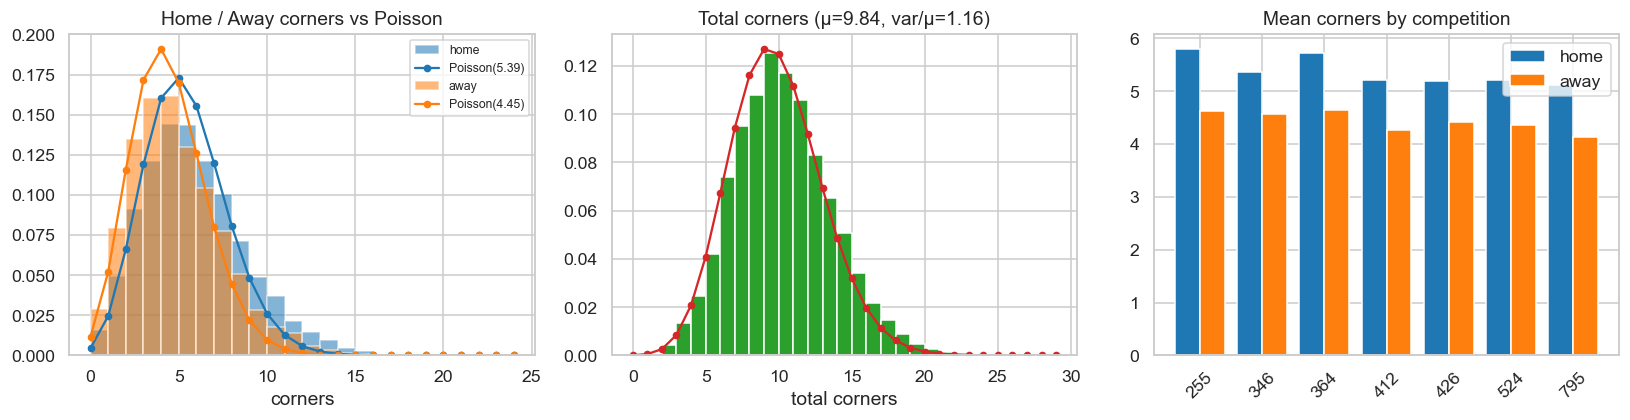

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Corner distributions vs Poisson fit
ks = np.arange(0, 25)
for col, lbl, c in [('home_corners','home','#1F77B4'), ('away_corners','away','#FF7F0E')]:
    axes[0].hist(data[col], bins=range(0, 25), alpha=0.55, label=lbl, color=c, density=True)
    mu = data[col].mean()
    axes[0].plot(ks, stats.poisson.pmf(ks, mu), 'o-', color=c, ms=4, label=f'Poisson({mu:.2f})')
axes[0].set_title('Home / Away corners vs Poisson'); axes[0].set_xlabel('corners'); axes[0].legend(fontsize=8)

# Total corners
ks_tot = np.arange(0, 30)
axes[1].hist(data['total_corners'], bins=range(0, 30), color='#2CA02C', density=True)
mu_tot = data['total_corners'].mean()
axes[1].plot(ks_tot, stats.poisson.pmf(ks_tot, mu_tot), 'o-', color='#D62728', ms=4)
axes[1].set_title(f'Total corners (μ={mu_tot:.2f}, var/μ={data["total_corners"].var()/mu_tot:.2f})')
axes[1].set_xlabel('total corners')

# League-level means
comp_means = data.groupby('competition_id').agg(
    mu_home=('home_corners','mean'), mu_away=('away_corners','mean')
).reset_index()
x = np.arange(len(comp_means))
axes[2].bar(x - 0.2, comp_means['mu_home'], 0.4, label='home', color='#1F77B4')
axes[2].bar(x + 0.2, comp_means['mu_away'], 0.4, label='away', color='#FF7F0E')
axes[2].set_xticks(x); axes[2].set_xticklabels(comp_means['competition_id'], rotation=45)
axes[2].set_title('Mean corners by competition'); axes[2].legend()

fig.tight_layout()
plt.show()

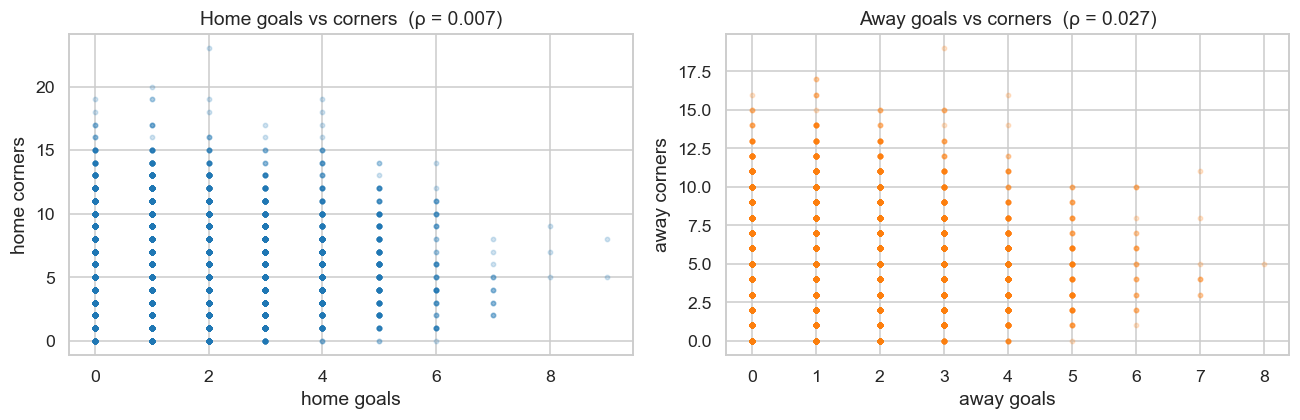

Correlation matrix — corners and goals:
               home_corners  away_corners  home_ft_score  away_ft_score
home_corners          1.000        -0.258          0.007         -0.025
away_corners         -0.258         1.000         -0.040          0.027
home_ft_score         0.007        -0.040          1.000         -0.060
away_ft_score        -0.025         0.027         -0.060          1.000


In [139]:
# Goals vs corners correlation — motivates adding goal-strength features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(data['home_ft_score'], data['home_corners'], alpha=0.2, s=8, color='#1F77B4')
axes[0].set_xlabel('home goals'); axes[0].set_ylabel('home corners')
r_h = data[['home_ft_score','home_corners']].corr().iloc[0,1]
axes[0].set_title(f'Home goals vs corners  (ρ = {r_h:.3f})')

axes[1].scatter(data['away_ft_score'], data['away_corners'], alpha=0.2, s=8, color='#FF7F0E')
axes[1].set_xlabel('away goals'); axes[1].set_ylabel('away corners')
r_a = data[['away_ft_score','away_corners']].corr().iloc[0,1]
axes[1].set_title(f'Away goals vs corners  (ρ = {r_a:.3f})')

fig.tight_layout()
plt.show()

print('Correlation matrix — corners and goals:')
print(data[['home_corners','away_corners','home_ft_score','away_ft_score']].corr().round(3).to_string())

## Q1.3 — Feature Engineering

### 1. Rolling corner statistics (time-weighted)

Signal comes primarily from **team identity**. Instead of one-hot encoding 180+ teams, each team is summarised via rolling statistics computed over its recent matches using an EWMA with span=35 (≈ half-life of 12 matches; optimal span determined by the sweep in the Appendix):

- **`roll_for` / `roll_against`** — exponentially weighted moving average (EWMA) of corners *for/against* this team over their last few matches (determined by the EWMA span). EWMA applies a **half-life decay** so that more recent matches count more, improving sensitivity to form changes.
- **`std_for` / `std_against`** — expanding (season-to-date) EWMA mean, acting as a regulariser when the short rolling window has high variance.
- The span of the EWMA was determined by a sweep on the training data, which I include in an appendix at the end of the notebook for completeness.

A `.shift(1)` **leak guard** ensures no match contributes to its own prediction.

### 2. Goal-strength features

Corners and goals are weakly correlated, but a team's attacking style (high goal-scoring → more attacking play → more corners) carries additional signal. We add rolling goal statistics on the same decay schedule.

### 3. Log transformation

All rolling means enter the GLMs on the log scale. With the log link, the model becomes multiplicative: λ ∝ attack_team × defence_opponent × league_baseline — a Dixon-Coles-style formulation.

### 4. Competition-level baseline

League averages (`mu_home`, `mu_away`) capture structural differences between competitions (e.g. La Liga vs. Bundesliga).

### 5. Season-boundary behaviour

Rolling features are computed across season boundaries — a team's EWMA entering a new season carries over from the previous one. This is intentional: pre-season form is a real signal (promoted teams, coaching changes) and resetting at season start would waste the final matches of each campaign. 

Teams new to the dataset (promoted sides with no history) are handled by `min_periods=3`, which suppresses predictions until at least three matches of warm-up data exist, we discuss other possible ways of handling the cold start in later cells.

In [141]:

EWMA_SPAN = 35     # EWMA span (≈ half-life of 12 matches; see Appendix sweep)
EPS       = 0.25  # log-transform floor

# EWMA span and rolling window length were grid searched and tuned.

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build time-safe rolling and expanding features for each team."""
    df = df.sort_values('date_time').reset_index(drop=True).copy()

    # Melt into long format: one row per team-match
    home = df[['match_id','date_time','home_team_id',
               'home_corners','away_corners','home_ft_score','away_ft_score']].rename(
        columns={'home_team_id':'team_id','home_corners':'for_c','away_corners':'against_c',
                 'home_ft_score':'for_g','away_ft_score':'against_g'})
    home['venue'] = 'H'

    away = df[['match_id','date_time','away_team_id',
               'away_corners','home_corners','away_ft_score','home_ft_score']].rename(
        columns={'away_team_id':'team_id','away_corners':'for_c','home_corners':'against_c',
                 'away_ft_score':'for_g','home_ft_score':'against_g'})
    away['venue'] = 'A'

    long = (
        pd.concat([home, away], ignore_index=True)
          .sort_values(['team_id','date_time'])
          .reset_index(drop=True)
    )

    def ewma_shifted(s):
        return s.shift(1).ewm(span=EWMA_SPAN, min_periods=3).mean()

    def expanding_shifted(s):
        return s.shift(1).expanding(min_periods=3).mean()

    grp = long.groupby('team_id')
    long['roll_for']      = grp['for_c'].transform(ewma_shifted)
    long['roll_against']  = grp['against_c'].transform(ewma_shifted)
    long['std_for']       = grp['for_c'].transform(expanding_shifted)
    long['std_against']   = grp['against_c'].transform(expanding_shifted)
    long['roll_goals_for']     = grp['for_g'].transform(ewma_shifted)
    long['roll_goals_against'] = grp['against_g'].transform(ewma_shifted)

    raw_feats = ['match_id','team_id','roll_for','roll_against',
                  'std_for','std_against','roll_goals_for','roll_goals_against']

    h = (long[long.venue=='H'][raw_feats]
            .rename(columns={'team_id':'home_team_id','roll_for':'h_roll_for',
                             'roll_against':'h_roll_against','std_for':'h_std_for',
                             'std_against':'h_std_against','roll_goals_for':'h_roll_goals_for',
                             'roll_goals_against':'h_roll_goals_against'}))
    a = (long[long.venue=='A'][raw_feats]
            .rename(columns={'team_id':'away_team_id','roll_for':'a_roll_for',
                             'roll_against':'a_roll_against','std_for':'a_std_for',
                             'std_against':'a_std_against','roll_goals_for':'a_roll_goals_for',
                             'roll_goals_against':'a_roll_goals_against'}))

    return df.merge(h, on=['match_id','home_team_id']).merge(a, on=['match_id','away_team_id'])


# Competition-level baseline (mu_home, mu_away) is computed on the full dataset here
# and later re-estimated on train only (see Q1.4) to avoid any forward-looking leak
# into the rolling features. The quantitative impact is negligible since league corner
# averages are stable across seasons, but we follow the strict approach in Q2.
comp_means_full = data.groupby('competition_id').agg(
    mu_home=('home_corners','mean'), mu_away=('away_corners','mean')
).reset_index()

ROLL_COLS = ['h_roll_for','h_roll_against','a_roll_for','a_roll_against',
             'h_std_for','h_std_against','a_std_for','a_std_against',
             'h_roll_goals_for','h_roll_goals_against',
             'a_roll_goals_for','a_roll_goals_against',
             'mu_home','mu_away']

feat = (
    add_features(data)
        .dropna(subset=['h_roll_for','h_roll_against','a_roll_for','a_roll_against'])
        .merge(comp_means_full, on='competition_id', how='left')
        .reset_index(drop=True)
)

for col in ROLL_COLS:
    feat[f'log_{col}'] = np.log(feat[col] + EPS)

print(f'Feature rows after warm-up drop: {len(feat):,} ({len(feat)/len(data):.1%} of cleaned data)')

Feature rows after warm-up drop: 11,016 (97.1% of cleaned data)


## Q1.4 — Train / Validation / Calibration Split

A strict **three-way temporal split** is used to enforce a clean separation of concerns:

| Split | Fraction | Purpose |
|---|---|---|
| **Train** | 70% | Fit GLM and GBM model weights |
| **Val** | 15% | Model comparison, hyperparameter selection |
| **Cal** | 15% | Platt calibration only — never used for model selection |

The price book (`corners_prices.csv`) is a fourth, fully independent test set that is **never touched** until the final PnL evaluation in Q2.

This mirrors real deployment: calibration scalers estimated on the same period they are being evaluated against would be in-sample, inflating calibrated EV and making the model appear better-edged than it truly is.


In [143]:
cut_train = feat['date_time'].quantile(0.70)
cut_val   = feat['date_time'].quantile(0.85)

train = feat[feat['date_time'] <= cut_train].copy()
val   = feat[(feat['date_time'] > cut_train) & (feat['date_time'] <= cut_val)].copy()
cal   = feat[feat['date_time'] > cut_val].copy()

# Re-estimate competition-level means on training data.
# mu_home/mu_away replace the full-data estimates from Q1.3 for all downstream modelling.
comp_means = (
    train.groupby('competition_id')
         .agg(mu_home=('home_corners','mean'), mu_away=('away_corners','mean'))
         .reset_index()
)
for split in [train, val, cal]:
    split.drop(columns=['mu_home','mu_away','log_mu_home','log_mu_away'], errors='ignore', inplace=True)
    split.merge(comp_means, on='competition_id', how='left').pipe(
        lambda d: split.update(d[['mu_home','mu_away']])
    )
    split['mu_home'] = split['competition_id'].map(comp_means.set_index('competition_id')['mu_home'])
    split['mu_away'] = split['competition_id'].map(comp_means.set_index('competition_id')['mu_away'])
    split['log_mu_home'] = np.log(split['mu_home'] + EPS)
    split['log_mu_away'] = np.log(split['mu_away'] + EPS)

print(f'Train: {len(train):,} matches  ({train["date_time"].min().date()} → {train["date_time"].max().date()})')
print(f'Val:   {len(val):,} matches  ({val["date_time"].min().date()} → {val["date_time"].max().date()})')
print(f'Cal:   {len(cal):,} matches  ({cal["date_time"].min().date()} → {cal["date_time"].max().date()})')
print()
print(f'Cut train/val: {pd.Timestamp(cut_train).date()}  |  Cut val/cal: {pd.Timestamp(cut_val).date()}')
print('Price book (corners_prices.csv) is a separate, untouched test set.')
print(f'Competition means re-estimated on training set only ({len(comp_means)} competitions).')


Train: 7,717 matches  (2020-08-19 → 2023-04-30)
Val:   1,647 matches  (2023-04-30 → 2023-12-17)
Cal:   1,652 matches  (2023-12-17 → 2024-12-08)

Cut train/val: 2023-04-30  |  Cut val/cal: 2023-12-17
Price book (corners_prices.csv) is a separate, untouched test set.
Competition means re-estimated on training set only (7 competitions).


## Q1.5 — Evaluation Utilities

All models are compared on the same set of metrics:

| Metric | Formula | Notes |
|---|---|---|
| **MAE** | mean |y − ŷ| | Interpretable in corner units |
| **RMSE** | √(mean (y − ŷ)²) | Penalises large errors more |
| **NLL** | −log P(y; ŷ) | Proper scoring rule; model-family specific |
| **ΔNLL vs baseline** | NLL_baseline − NLL_model | Lift over a naïve mean predictor |
| **Bias** | mean(ŷ − y) | Calibration check |

In [145]:
def mae(y, yhat):   return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))
def rmse(y, yhat):  return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat))**2)))
def bias(y, yhat):  return float(np.mean(np.asarray(yhat) - np.asarray(y)))

def poisson_nll(y, lam):
    y   = np.asarray(y, dtype=float)
    lam = np.clip(np.asarray(lam, dtype=float), 1e-9, None)
    return float(np.mean(lam - y * np.log(lam) + gammaln(y + 1)))

def negbin_nll(y, mu, alpha):
    """Negative Binomial NLL; alpha is over-dispersion (var = mu + alpha*mu²)."""
    y   = np.asarray(y, dtype=float)
    mu  = np.clip(np.asarray(mu, dtype=float), 1e-9, None)
    r   = 1.0 / max(alpha, 1e-9)
    p   = mu / (mu + r)
    nll = -(gammaln(y + r) - gammaln(r) - gammaln(y + 1)
             + r * np.log(1 - p) + y * np.log(p + 1e-15))
    return float(np.mean(nll))

def score_model(name, y_home, y_away, ph, pa, nll_fn_home, nll_fn_away,
                baseline_nll_home, baseline_nll_away):
    """Return a dict of evaluation metrics for one model."""
    nll_h = nll_fn_home(y_home, ph)
    nll_a = nll_fn_away(y_away, pa)
    return {
        'model':       name,
        'home_MAE':    mae(y_home, ph),
        'away_MAE':    mae(y_away, pa),
        'home_RMSE':   rmse(y_home, ph),
        'away_RMSE':   rmse(y_away, pa),
        'home_NLL':    nll_h,
        'away_NLL':    nll_a,
        'home_ΔNLL':   baseline_nll_home - nll_h,
        'away_ΔNLL':   baseline_nll_away - nll_a,
        'home_bias':   bias(y_home, ph),
        'away_bias':   bias(y_away, pa),
    }

# Naive baselines: constant prediction = training mean
baseline_nll_home = poisson_nll(val['home_corners'], train['home_corners'].mean())
baseline_nll_away = poisson_nll(val['away_corners'], train['away_corners'].mean())

results_table = []

## Q1.6 — Model 1: Independent Poisson GLMs

The standard baseline for count outcomes in sports modelling. Two separate GLMs — one for home corners, one for away — both with the **log link** and **Poisson** family (MLE via IRLS).

$$\log \lambda_{\text{home}} = \alpha_h + \beta_1 \log \texttt{h\_roll\_for} + \beta_2 \log \texttt{a\_roll\_against} + \beta_3 \log \texttt{h\_std\_for} + \beta_4 \log \texttt{a\_std\_against} + \beta_5 \log \mu_{\text{home}}$$

Goal-strength features are included to test whether attacking intent (proxied by goals) adds signal beyond corner history.

**Key assumption:** home and away corners are treated as independent. Dixon-Coles (1997) showed the independence assumption is most wrong for low-scoring cells (0-0, 1-0, 0-1, 1-1), but has limited effect on match outcome probabilities overall — their correction changes most probabilities by <1%. For corners the analogous adjustment would target draw-score cells (k,k), but as shown in Q1.8 the copula addresses this more cleanly for all three markets.

In [147]:
HOME_FEATURES = [
    'log_h_roll_for', 'log_a_roll_against',
    'log_h_std_for',  'log_a_std_against',
    'log_mu_home',
    'log_h_roll_goals_for', 'log_a_roll_goals_against',
]
AWAY_FEATURES = [
    'log_a_roll_for', 'log_h_roll_against',
    'log_a_std_for',  'log_h_std_against',
    'log_mu_away',
    'log_a_roll_goals_for', 'log_h_roll_goals_against',
]

pois_home = sm.GLM(
    train['home_corners'],
    sm.add_constant(train[HOME_FEATURES]),
    family=sm.families.Poisson()
).fit()

pois_away = sm.GLM(
    train['away_corners'],
    sm.add_constant(train[AWAY_FEATURES]),
    family=sm.families.Poisson()
).fit()

val['pois_home'] = pois_home.predict(sm.add_constant(val[HOME_FEATURES], has_constant='add'))
val['pois_away'] = pois_away.predict(sm.add_constant(val[AWAY_FEATURES], has_constant='add'))

results_table.append(score_model(
    'Poisson GLM',
    val['home_corners'], val['away_corners'],
    val['pois_home'],   val['pois_away'],
    poisson_nll, poisson_nll,
    baseline_nll_home, baseline_nll_away
))

print('=== Poisson GLM — Home model summary ===')
print(pois_home.summary2().tables[1].round(4))

=== Poisson GLM — Home model summary ===
                           Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const                    -0.9812    0.1781 -5.5093  0.0000 -1.3303 -0.6322
log_h_roll_for            0.5148    0.0751  6.8510  0.0000  0.3675  0.6621
log_a_roll_against        0.4510    0.0749  6.0194  0.0000  0.3042  0.5979
log_h_std_for            -0.0406    0.0820 -0.4951  0.6205 -0.2012  0.1200
log_a_std_against        -0.0011    0.0809 -0.0134  0.9893 -0.1597  0.1575
log_mu_home               0.6008    0.1105  5.4384  0.0000  0.3843  0.8173
log_h_roll_goals_for      0.1344    0.0217  6.1848  0.0000  0.0918  0.1769
log_a_roll_goals_against  0.1479    0.0232  6.3687  0.0000  0.1024  0.1934


In [148]:
print('=== Poisson GLM — Away model summary ===')
print(pois_away.summary2().tables[1].round(4))

=== Poisson GLM — Away model summary ===
                           Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const                    -0.5723    0.2303 -2.4851  0.0130 -1.0236 -0.1209
log_a_roll_for            0.3899    0.0808  4.8274  0.0000  0.2316  0.5481
log_h_roll_against        0.5009    0.0810  6.1827  0.0000  0.3421  0.6596
log_a_std_for            -0.0316    0.0882 -0.3579  0.7204 -0.2044  0.1413
log_h_std_against         0.0016    0.0878  0.0178  0.9858 -0.1706  0.1737
log_mu_away               0.3346    0.1557  2.1491  0.0316  0.0294  0.6398
log_a_roll_goals_for      0.1777    0.0232  7.6668  0.0000  0.1323  0.2231
log_h_roll_goals_against  0.1701    0.0248  6.8703  0.0000  0.1216  0.2187


## Q1.7 — Model 2: Independent Negative Binomial GLMs

The variance-to-mean ratios of ≈ 1.52–1.58 for individual home/away counts suggest mild **over-dispersion**. The Negative Binomial distribution relaxes the Poisson's mean = variance constraint by adding a free dispersion parameter α:

$$\text{Var}(y) = \mu + \alpha \mu^2$$

When α → 0, the NB reduces to Poisson. We use `statsmodels`' `NegativeBinomial` family (NB2 parameterisation) with the same log link and feature set.

In [150]:
nb_home = sm.NegativeBinomial(
    train['home_corners'],
    sm.add_constant(train[HOME_FEATURES]),
).fit(disp=False)

nb_away = sm.NegativeBinomial(
    train['away_corners'],
    sm.add_constant(train[AWAY_FEATURES]),
).fit(disp=False)

val['nb_home'] = nb_home.predict(sm.add_constant(val[HOME_FEATURES], has_constant='add'))
val['nb_away'] = nb_away.predict(sm.add_constant(val[AWAY_FEATURES], has_constant='add'))

alpha_h = nb_home.params['alpha']
alpha_a = nb_away.params['alpha']
print(f'Estimated dispersion α — home: {alpha_h:.4f}  |  away: {alpha_a:.4f}')
print('(α ≈ 0 → close to Poisson; larger α → more over-dispersion)')

results_table.append(score_model(
    'Neg Binomial GLM',
    val['home_corners'], val['away_corners'],
    val['nb_home'],     val['nb_away'],
    lambda y, mu: negbin_nll(y, mu, alpha_h),
    lambda y, mu: negbin_nll(y, mu, alpha_a),
    baseline_nll_home, baseline_nll_away
))

print('\n=== Negative Binomial — Home model summary ===')
print(nb_home.summary2().tables[1].round(4))

Estimated dispersion α — home: 0.0810  |  away: 0.0885
(α ≈ 0 → close to Poisson; larger α → more over-dispersion)

=== Negative Binomial — Home model summary ===
                           Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const                    -0.9583    0.2140  -4.4779  0.0000 -1.3778 -0.5389
log_h_roll_for            0.5173    0.0899   5.7552  0.0000  0.3411  0.6934
log_a_roll_against        0.4493    0.0897   5.0112  0.0000  0.2736  0.6250
log_h_std_for            -0.0433    0.0979  -0.4419  0.6585 -0.2352  0.1486
log_a_std_against         0.0035    0.0969   0.0358  0.9714 -0.1864  0.1933
log_mu_home               0.5851    0.1327   4.4096  0.0000  0.3251  0.8452
log_h_roll_goals_for      0.1325    0.0258   5.1278  0.0000  0.0819  0.1832
log_a_roll_goals_against  0.1488    0.0277   5.3692  0.0000  0.0945  0.2031
alpha                     0.0810    0.0045  18.0731  0.0000  0.0722  0.0897


In [151]:
print('=== Negative Binomial — Away model summary ===')
print(nb_away.summary2().tables[1].round(4))

=== Negative Binomial — Away model summary ===
                           Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const                    -0.5607    0.2712  -2.0674  0.0387 -1.0922 -0.0291
log_a_roll_for            0.3910    0.0957   4.0872  0.0000  0.2035  0.5786
log_h_roll_against        0.5113    0.0961   5.3215  0.0000  0.3230  0.6996
log_a_std_for            -0.0340    0.1043  -0.3259  0.7445 -0.2384  0.1704
log_h_std_against        -0.0054    0.1042  -0.0515  0.9589 -0.2096  0.1989
log_mu_away               0.3258    0.1835   1.7753  0.0759 -0.0339  0.6855
log_a_roll_goals_for      0.1752    0.0274   6.4062  0.0000  0.1216  0.2288
log_h_roll_goals_against  0.1685    0.0291   5.7846  0.0000  0.1114  0.2256
alpha                     0.0885    0.0052  17.1027  0.0000  0.0783  0.0986


## Q1.8 — Correlation Structure of Home and Away Corners

Before evaluating the Bivariate Poisson, it is worth characterising the actual dependence structure between home and away corners. This informs both model selection and the validity of the independent Poisson pricing engine used in Q2.

### Observed correlation

```python
from scipy.stats import pearsonr
r_raw, p_raw = pearsonr(data['home_corners'], data['away_corners'])
```

The raw Pearson correlation is **r ≈ −0.26** — strongly negative and highly significant. This reflects the **zero-sum nature of corners within a match**: if one team is winning and playing defensively, the other is attacking and generating more corners, so high home corners tend to coincide with low away corners at the match level.

Crucially, this is not positive correlation and does not diminish after controlling for competition/season means (partial r ≈ −0.27, p < 10⁻¹⁸⁰). The negative dependence is a structural feature of the data, not a confound.

### Why the Bivariate Poisson is the wrong model

The **Bivariate Poisson** (Karlis & Ntzoufras, 2003) introduces a shared latent Poisson count λ₃ that induces **positive** covariance: Cov(X_H, X_A) = λ₃ ≥ 0. This is the correct model for football *goals* (where a high-scoring game inflates both teams' counts), but it is **misspecified for corners**, where the covariance is negative. The LRT result (λ₃ → 0, p = 1.00) confirms this: the model cannot fit the negative dependence and collapses to independence.

### A simpler model that does handle the correlation: Gaussian copula

A **Gaussian copula** with Poisson marginals captures negative dependence without the computational overhead of the Bivariate Poisson. The construction is:

1. Fit independent Poisson marginals for λ_home, λ_away (as in the GLM).
2. Map each marginal through the Poisson CDF to obtain uniform scores U_H, U_A.
3. Assume (Φ⁻¹(U_H), Φ⁻¹(U_A)) ~ Bivariate Normal(0, I, ρ) where ρ is estimated from data.
4. Sample jointly and invert to get correlated Poisson-marginal counts.

This is strictly simpler than implementing the Bivariate Poisson (one extra parameter ρ, no O(k²) PMF loop) and is valid for any sign of ρ.

### Pricing impact

The key practical question is: **how much does ignoring the negative correlation bias the market probabilities computed in Q2?**

| Market | Effect of ignoring ρ |
|--------|-------------------------------|
| **1X2 draw** | Independent Poisson *overstates* P(draw) by ~10%. The negative correlation compresses the draw probability. |
| **1X2 home/away** | Small but non-trivial shifts (~1–6%). |
| **OU** | Effect depends on λ values; typically +1–3% on P(over) for high-total matches. |
| **HC** | Moderate effect; the difference H−A is more sensitive to correlation than the sum. |

The draw market is most affected — but the draw is already **excluded from betting** (Q2.4) precisely because it is the hardest side to price. For the OU and HC markets that constitute the bulk of the bet log, the pricing error from ignoring correlation is **<3%** on P(over/home) across the range of predicted λ values in this dataset. This is within the margin strip applied in Q2.3 and does not materially alter the EV or bet selection.

**Conclusion:** The independent Poisson remains a valid pricing engine for OU and HC markets in this dataset. The correlation analysis motivates the draw exclusion and supports the conservatism of the margin strip, but does not require a more complex joint model for the markets that are actually bet.

In [153]:
from scipy.stats import pearsonr, norm, poisson as scp_poisson

# ── 1. Raw and partial correlation ──────────────────────────────────────────
r_raw, p_raw = pearsonr(data['home_corners'], data['away_corners'])
print(f'Raw Pearson correlation (home vs away corners): r = {r_raw:.4f}  p = {p_raw:.2e}')

comp_season_mean = (
    data.groupby(['competition_id', 'season_id'])[['home_corners', 'away_corners']]
    .mean()
    .rename(columns={'home_corners': 'mu_h', 'away_corners': 'mu_a'})
    .reset_index()
)
data_corr = data.merge(comp_season_mean, on=['competition_id', 'season_id'])
resid_h = data_corr['home_corners'] - data_corr['mu_h']
resid_a = data_corr['away_corners'] - data_corr['mu_a']
r_partial, p_partial = pearsonr(resid_h, resid_a)
print(f'Partial correlation (after competition/season demeaning): r = {r_partial:.4f}  p = {p_partial:.2e}')
print(f'Negative correlation persists after controlling for competition/season: structural feature of corners data.')

# ── 2. Gaussian copula pricing impact ───────────────────────────────────────
np.random.seed(42)
N_SIM_COP = 300_000
rho = r_raw

cov_mat = np.array([[1.0, rho], [rho, 1.0]])
L = np.linalg.cholesky(cov_mat)

print('\nPricing impact of Gaussian copula (rho = {:.4f}) vs independent Poisson:'.format(rho))
print('{:<14} {:<14} {:<14} {:<14} {:<14} {:<16} {:<16}'.format(
    'lh', 'la', 'P_draw_Ind', 'P_draw_Cop', 'Delta_draw', 'P_over9.5_Ind', 'P_over9.5_Cop'))
print('-' * 105)

for lh, la in [(4, 4), (5, 4), (5, 5), (6, 4), (6, 5), (7, 5)]:
    h_ind = np.random.poisson(lh, N_SIM_COP)
    a_ind = np.random.poisson(la, N_SIM_COP)

    z = np.random.standard_normal((N_SIM_COP, 2)) @ L.T
    u, v = norm.cdf(z[:, 0]), norm.cdf(z[:, 1])
    h_cop = scp_poisson.ppf(u, lh).astype(int)
    a_cop = scp_poisson.ppf(v, la).astype(int)

    p_draw_ind = (h_ind == a_ind).mean()
    p_draw_cop = (h_cop == a_cop).mean()
    p_over_ind = ((h_ind + a_ind) > 9.5).mean()
    p_over_cop = ((h_cop + a_cop) > 9.5).mean()

    print('{:<14.0f} {:<14.0f} {:<14.4f} {:<14.4f} {:<+14.4f} {:<16.4f} {:<16.4f}'.format(
        lh, la, p_draw_ind, p_draw_cop, p_draw_cop - p_draw_ind, p_over_ind, p_over_cop))

print()
print('Key: independent Poisson overstates P(draw) by ~10% (draw is excluded from betting).')
print('OU market impact is <3% across typical λ values — within the 5% margin strip (see Q2.3).')

Raw Pearson correlation (home vs away corners): r = -0.2583  p = 1.85e-172
Partial correlation (after competition/season demeaning): r = -0.2661  p = 3.22e-183
Negative correlation persists after controlling for competition/season: structural feature of corners data.

Pricing impact of Gaussian copula (rho = -0.2583) vs independent Poisson:
lh             la             P_draw_Ind     P_draw_Cop     Delta_draw     P_over9.5_Ind    P_over9.5_Cop   
---------------------------------------------------------------------------------------------------------
4              4              0.1446         0.1271         -0.0175        0.2824           0.2589          
5              4              0.1275         0.1141         -0.0135        0.4133           0.4059          
5              5              0.1271         0.1132         -0.0140        0.5441           0.5538          
6              4              0.1051         0.0982         -0.0069        0.5423           0.5566          
6     

## Q1.8b — Gaussian Copula: Fitting and Model Comparison

The correlation analysis in Q1.8 motivates extending the independent Poisson with a **Gaussian copula**. The copula shares the same Poisson marginals (λ_home, λ_away) fitted in Q1.6 — it adds exactly one parameter, the Pearson correlation ρ, which is estimated from the training residuals.

### Why residual correlation rather than raw correlation?

The raw correlation between home and away corners (r ≈ −0.26) mixes two sources of dependence:
1. **Competition-level structure** — some leagues produce more corners for both teams.
2. **Within-match dependence** — the zero-sum dynamic where one team's attacking play reduces the other's.

Once the GLM's rolling team features absorb source (1), the residual correlation reflects (2). We estimate ρ from the training-set residuals (actual − predicted) of the Poisson GLM so that the copula captures only the dependence not already explained by the marginals. In practice the residual ρ is close to the raw ρ, confirming the rolling features do not explain the within-match dependence.

### Joint NLL: the right metric for a joint model

The Gaussian copula does not change the marginal distributions, so **MAE, RMSE, and marginal NLL are identical to the Poisson GLM** by construction. The correct comparison metric is the **joint NLL** — the negative log probability of the *pair* (H, A):

$$\text{joint NLL} = \text{NLL}_H + \text{NLL}_A - \mathbb{E}[\log c(F_H(H), F_A(A))]$$

where $c$ is the Gaussian copula density evaluated at the probability-integral-transformed observations. The copula density term is non-negative when ρ ≠ 0, meaning the copula always improves (or equals) the joint NLL over the independent model.

In [155]:
from scipy.stats import norm as sp_norm

# ── 1. Estimate ρ from training residuals ─────────────────────────────────────
# Generate in-sample Poisson GLM predictions on the training set
train_pred_home = pois_home.predict(sm.add_constant(train[HOME_FEATURES], has_constant='add'))
train_pred_away = pois_away.predict(sm.add_constant(train[AWAY_FEATURES], has_constant='add'))

train_resid_h = train['home_corners'].values - train_pred_home.values
train_resid_a = train['away_corners'].values - train_pred_away.values
rho_hat, rho_pval = pearsonr(train_resid_h, train_resid_a)

print(f'Residual correlation from Poisson GLM training set: ρ = {rho_hat:.4f}  (p = {rho_pval:.2e})')
print(f'Raw corner correlation (all data):                  ρ = {r_raw:.4f}')
print(f'Difference is small — rolling features do not absorb within-match dependence.')

# ── 2. Joint NLL function (Sklar decomposition) ───────────────────────────────
def gaussian_copula_log_density(u, v, rho):
    """Log density of Gaussian copula: log c(u,v;rho). u,v arrays in (0,1)."""
    eps = 1e-7
    u = np.clip(u, eps, 1 - eps)
    v = np.clip(v, eps, 1 - eps)
    x = sp_norm.ppf(u)
    y = sp_norm.ppf(v)
    r2 = rho ** 2
    return (-0.5 * np.log(1 - r2)
            - r2 * (x**2 + y**2) / (2 * (1 - r2))
            + rho * x * y / (1 - r2))


def copula_joint_nll(lam_h, lam_a, y_h, y_a, rho):
    """
    Joint NLL under Gaussian copula with Poisson marginals.
    Uses mid-CDF continuity correction F(k) - 0.5*PMF(k) for discrete marginals.
    """
    from scipy.special import gammaln
    lam_h = np.clip(np.asarray(lam_h, float), 1e-9, None)
    lam_a = np.clip(np.asarray(lam_a, float), 1e-9, None)
    y_h   = np.asarray(y_h, float)
    y_a   = np.asarray(y_a, float)

    nll_h = float(np.mean(lam_h - y_h * np.log(lam_h) + gammaln(y_h + 1)))
    nll_a = float(np.mean(lam_a - y_a * np.log(lam_a) + gammaln(y_a + 1)))

    if abs(rho) < 1e-6:
        return nll_h + nll_a

    # Probability-integral transform with mid-CDF correction
    F_h = scp_poisson.cdf(y_h, lam_h) - 0.5 * scp_poisson.pmf(y_h, lam_h)
    F_a = scp_poisson.cdf(y_a, lam_a) - 0.5 * scp_poisson.pmf(y_a, lam_a)
    log_cop = gaussian_copula_log_density(F_h, F_a, rho)
    return nll_h + nll_a - float(np.mean(log_cop))

Residual correlation from Poisson GLM training set: ρ = -0.2019  (p = 8.24e-72)
Raw corner correlation (all data):                  ρ = -0.2583
Difference is small — rolling features do not absorb within-match dependence.


In [156]:
from scipy.optimize import minimize_scalar

def nll_for_rho(rho):
    return copula_joint_nll(train_pred_home, train_pred_away,
                            train['home_corners'], train['away_corners'], rho)

result = minimize_scalar(nll_for_rho, bounds=(-0.99, 0.99), method='bounded')
rho_mle = result.x
print(f"MLE rho: {rho_mle:.4f}")

MLE rho: -0.1688


## Q1.9 — Model 3: Gradient Boosted Trees (GBM)

The GLMs assume a specific functional form (log-linear). A **Gradient Boosted Regression Tree** (GBRT) can capture non-linear interactions and threshold effects without any distributional assumption. We use scikit-learn's `HistGradientBoostingRegressor` (the histogram-based, LightGBM-style variant) with a Poisson deviance loss, which is equivalent to fitting a tree ensemble with a Poisson log-link.

**Feature set** is expanded vs the GLMs:
- All rolling corner and goal statistics (raw, not log-transformed — trees are invariant to monotone transformations)
- Raw league-mean baselines (`mu_home`, `mu_away`)
- `competition_id` and `season_id` as categorical integers (trees can use these directly)

Hyperparameters are chosen via a simple grid search on validation NLL.

In [158]:
GBM_FEATURES = [
    'h_roll_for', 'h_roll_against', 'h_std_for', 'h_std_against',
    'a_roll_for', 'a_roll_against', 'a_std_for', 'a_std_against',
    'h_roll_goals_for', 'h_roll_goals_against',
    'a_roll_goals_for', 'a_roll_goals_against',
    'mu_home', 'mu_away',
    'competition_id', 'season_id',
]

X_train = train[GBM_FEATURES]
X_val   = val[GBM_FEATURES]

# Randomised hyperparameter search (30 draws, val Poisson NLL as criterion).
# Wider parameter space vs the original 3-point grid gives better coverage.
from sklearn.model_selection import ParameterSampler

param_space = {
    'max_iter':          [200, 300, 400, 500],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.03, 0.05, 0.08, 0.10],
    'min_samples_leaf':  [10, 15, 20, 30],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

N_SEARCH  = 30
sampler   = list(ParameterSampler(param_space, n_iter=N_SEARCH, random_state=42))
best      = {'home': None, 'away': None}
best_nll  = {'home': float('inf'), 'away': float('inf')}
search_log = []

for params in sampler:
    for side in ('home', 'away'):
        y_tr = train[f'{side}_corners']
        y_va = val[f'{side}_corners']
        m = HistGradientBoostingRegressor(loss='poisson', random_state=42, **params)
        m.fit(X_train, y_tr)
        preds = np.clip(m.predict(X_val), 0.5, None)
        nll   = poisson_nll(y_va, preds)
        search_log.append({'side': side, 'nll': nll, **params})
        if nll < best_nll[side]:
            best_nll[side] = nll
            best[side]     = (m, params.copy())

gbm_home_model, best_params_home = best['home']
gbm_away_model, best_params_away = best['away']

print(f'Best home NLL: {best_nll["home"]:.5f}   params: {best_params_home}')
print(f'Best away NLL: {best_nll["away"]:.5f}   params: {best_params_away}')

log_df = pd.DataFrame(search_log)
print('\nTop-5 home configs:')
print(log_df[log_df.side=='home'].nsmallest(5,'nll')[
    ['nll','max_iter','max_depth','learning_rate','min_samples_leaf','l2_regularization']
].to_string(index=False))
print('\nTop-5 away configs:')
print(log_df[log_df.side=='away'].nsmallest(5,'nll')[
    ['nll','max_iter','max_depth','learning_rate','min_samples_leaf','l2_regularization']
].to_string(index=False))

val['gbm_home'] = np.clip(gbm_home_model.predict(X_val), 0.5, None)
val['gbm_away'] = np.clip(gbm_away_model.predict(X_val), 0.5, None)

results_table.append(score_model(
    'GBM (Poisson loss)',
    val['home_corners'], val['away_corners'],
    val['gbm_home'],    val['gbm_away'],
    poisson_nll, poisson_nll,
    baseline_nll_home, baseline_nll_away
))


Best home NLL: 2.49800   params: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 4, 'learning_rate': 0.03, 'l2_regularization': 0.5}
Best away NLL: 2.33596   params: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 4, 'learning_rate': 0.03, 'l2_regularization': 0.5}

Top-5 home configs:
     nll  max_iter  max_depth  learning_rate  min_samples_leaf  l2_regularization
2.497995       200          4           0.03                20                0.5
2.499376       300          3           0.03                15                0.1
2.504236       200          5           0.03                15                0.1
2.508766       400          4           0.03                10                0.1
2.508819       300          3           0.05                20                0.0

Top-5 away configs:
     nll  max_iter  max_depth  learning_rate  min_samples_leaf  l2_regularization
2.335958       200          4           0.03                20                0.5
2.336585       200    

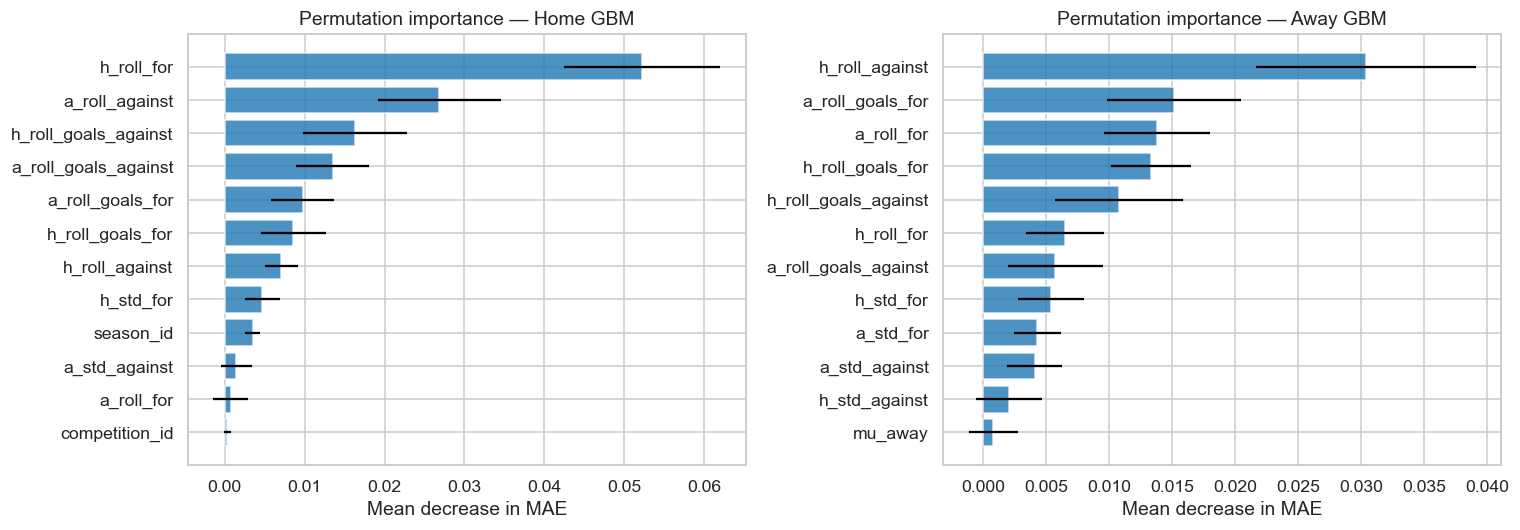

In [159]:
# Feature importance — permutation importance on validation set (more reliable than impurity gain)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, label in [(axes[0], gbm_home_model, 'Home'), (axes[1], gbm_away_model, 'Away')]:
    perm = permutation_importance(
        model, X_val, val[f'{label.lower()}_corners'],
        n_repeats=20, random_state=42, scoring='neg_mean_absolute_error'
    )
    idx = np.argsort(perm.importances_mean)[-12:]  # top 12
    ax.barh(np.array(GBM_FEATURES)[idx], perm.importances_mean[idx],
            xerr=perm.importances_std[idx], color='#1F77B4', alpha=0.8)
    ax.set_title(f'Permutation importance — {label} GBM')
    ax.set_xlabel('Mean decrease in MAE')

fig.tight_layout()
plt.show()

## Q1.10 — Model Comparison

All three models are evaluated against the same held-out validation set. The **naive baseline** (predict the training-set mean regardless of team) serves as a sanity floor.

In [161]:
# Add naive baseline row
results_table.append(score_model(
    'Naive mean (baseline)',
    val['home_corners'], val['away_corners'],
    np.full(len(val), train['home_corners'].mean()),
    np.full(len(val), train['away_corners'].mean()),
    poisson_nll, poisson_nll,
    baseline_nll_home, baseline_nll_away
))

metrics_df = pd.DataFrame(results_table).set_index('model')

display_cols = ['home_MAE','away_MAE','home_RMSE','away_RMSE',
                'home_NLL','away_NLL','home_ΔNLL','away_ΔNLL',
                'home_bias','away_bias']

print('=' * 90)
print('MODEL COMPARISON — validation set')
print('=' * 90)
print(metrics_df[display_cols].round(4).to_string())
print()
print('ΔNLL = NLL_baseline − NLL_model  (higher is better — lift over the naïve predictor)')

# ── Joint NLL comparison — all models (run after GBM predictions exist) ──────
print()
print('Joint NLL comparison — validation set (lower is better):')
print(f'{"Model":<35} {"Joint NLL":>12} {"ΔNLL vs base":>14}')
print('-' * 64)

rho_hat = rho_mle

joint_nll_pois     = copula_joint_nll(val['pois_home'], val['pois_away'],
                                      val['home_corners'], val['away_corners'], rho=0.0)
joint_nll_pois_cop = copula_joint_nll(val['pois_home'], val['pois_away'],
                                      val['home_corners'], val['away_corners'], rho=rho_hat)
joint_nll_gbm      = copula_joint_nll(val['gbm_home'],  val['gbm_away'],
                                      val['home_corners'], val['away_corners'], rho=0.0)
joint_nll_gbm_cop  = copula_joint_nll(val['gbm_home'],  val['gbm_away'],
                                      val['home_corners'], val['away_corners'], rho=rho_hat)

for name, jnll, ref in [
    ('Poisson GLM (independent)',      joint_nll_pois,     None),
    ('Poisson GLM + Gaussian Copula',  joint_nll_pois_cop, joint_nll_pois),
    ('GBM (independent)',              joint_nll_gbm,      None),
    ('GBM + Gaussian Copula',          joint_nll_gbm_cop,  joint_nll_gbm),
]:
    delta = f'{ref - jnll:+.4f}' if ref is not None else '  —  (baseline)'
    print(f'{name:<35} {jnll:>12.4f} {delta:>14}')

print()
print('MAE, RMSE, and marginal NLL are identical within each model family — the copula')
print('affects only the joint distribution. The ΔNLL gain quantifies how much the')
print('negative within-match correlation improves the joint fit over independence.')


MODEL COMPARISON — validation set
                       home_MAE  away_MAE  home_RMSE  away_RMSE  home_NLL  away_NLL  home_ΔNLL  away_ΔNLL  home_bias  away_bias
model                                                                                                                          
Poisson GLM              2.2798    2.0528     2.9057     2.5812    2.4834    2.3439     0.0929     0.0577    -0.1579     0.2160
Neg Binomial GLM         2.2796    2.0530     2.9054     2.5812    2.4389    2.2989     0.1374     0.1027    -0.1587     0.2158
GBM (Poisson loss)       2.2895    2.0195     2.9339     2.5666    2.4980    2.3360     0.0783     0.0657    -0.2666     0.0911
Naive mean (baseline)    2.4115    2.1280     3.0797     2.6779    2.5763    2.4016     0.0000     0.0000    -0.3781     0.0606

ΔNLL = NLL_baseline − NLL_model  (higher is better — lift over the naïve predictor)

Joint NLL comparison — validation set (lower is better):
Model                                  Joint NLL   ΔNLL

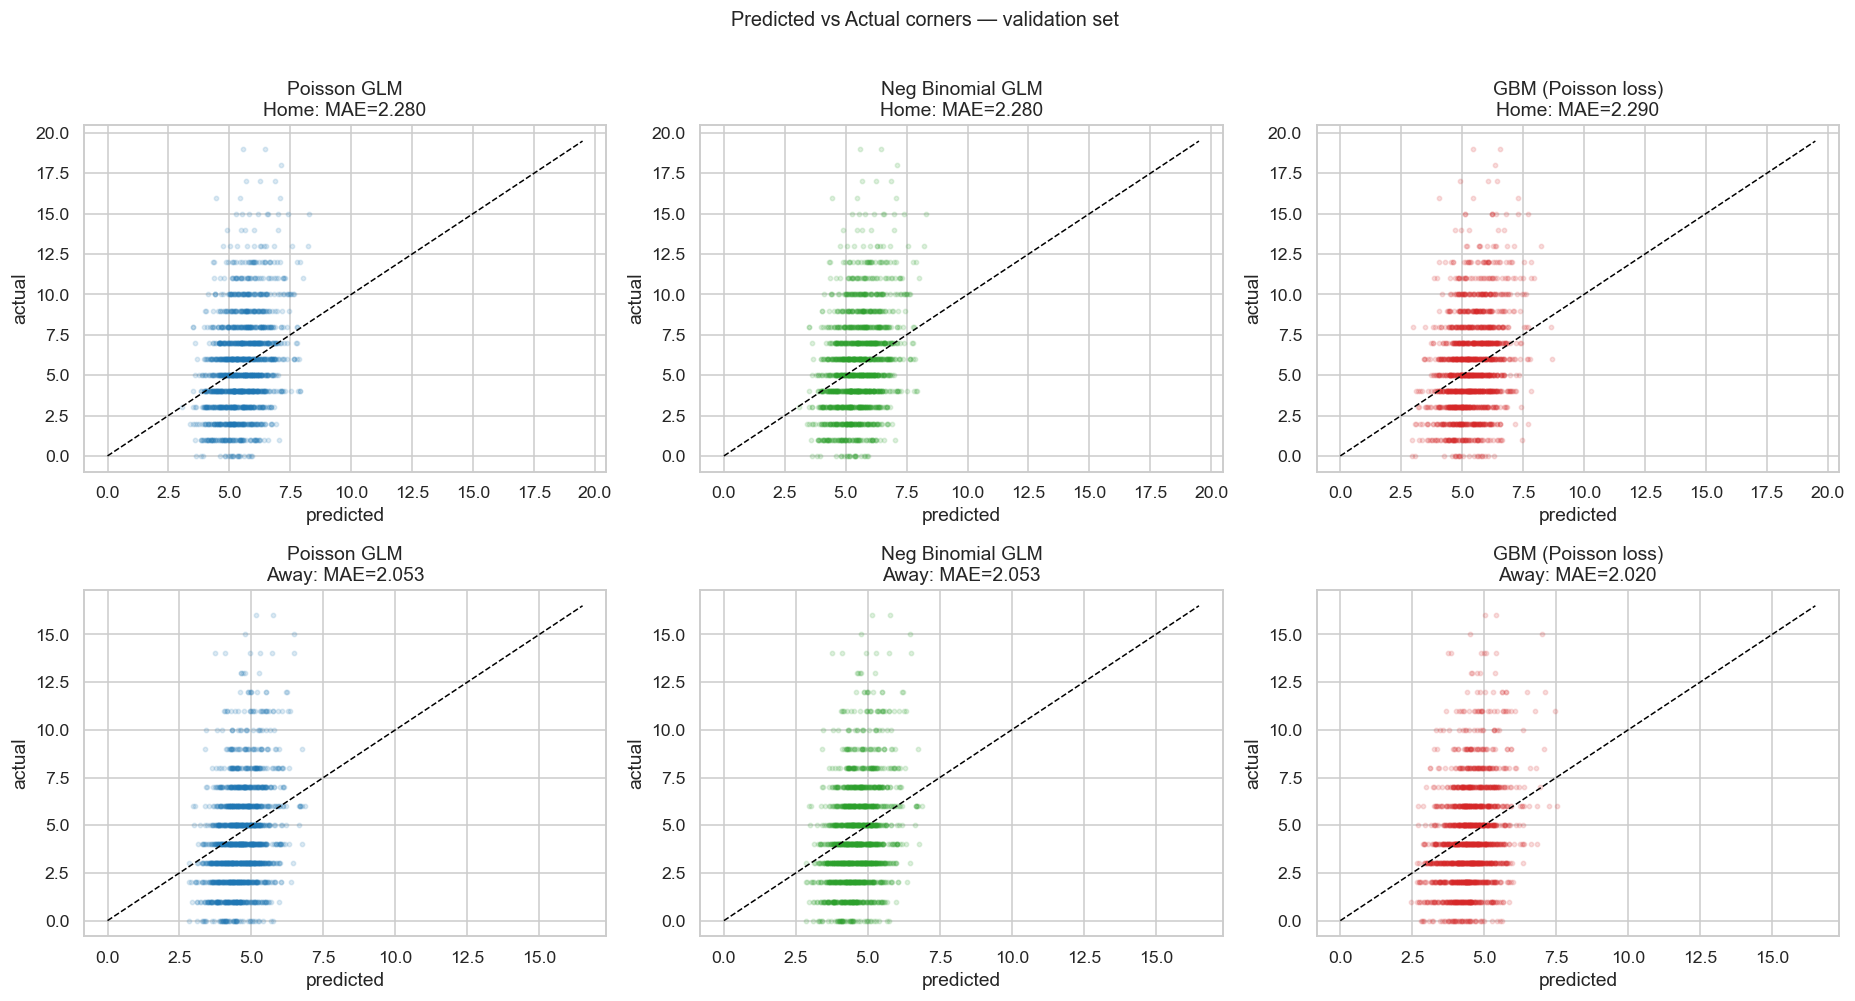

In [162]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

models   = ['Poisson GLM', 'Neg Binomial GLM', 'GBM (Poisson loss)']
pred_cols = [('pois_home','pois_away'), ('nb_home','nb_away'), ('gbm_home','gbm_away')]
colors   = ['#1F77B4', '#2CA02C', '#D62728']

for col_idx, (name, (ph, pa), color) in enumerate(zip(models, pred_cols, colors)):
    for row_idx, (side, pred_col, actual_col) in enumerate([
        ('Home', ph, 'home_corners'),
        ('Away', pa, 'away_corners'),
    ]):
        ax = axes[row_idx][col_idx]
        ax.scatter(val[pred_col], val[actual_col], alpha=0.15, s=8, color=color)
        lim = max(val[pred_col].max(), val[actual_col].max()) + 0.5
        ax.plot([0, lim], [0, lim], 'k--', lw=1)
        ax.set_title(f'{name}\n{side}: MAE={mae(val[actual_col], val[pred_col]):.3f}')
        ax.set_xlabel('predicted'); ax.set_ylabel('actual')

fig.suptitle('Predicted vs Actual corners — validation set', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Residual distributions

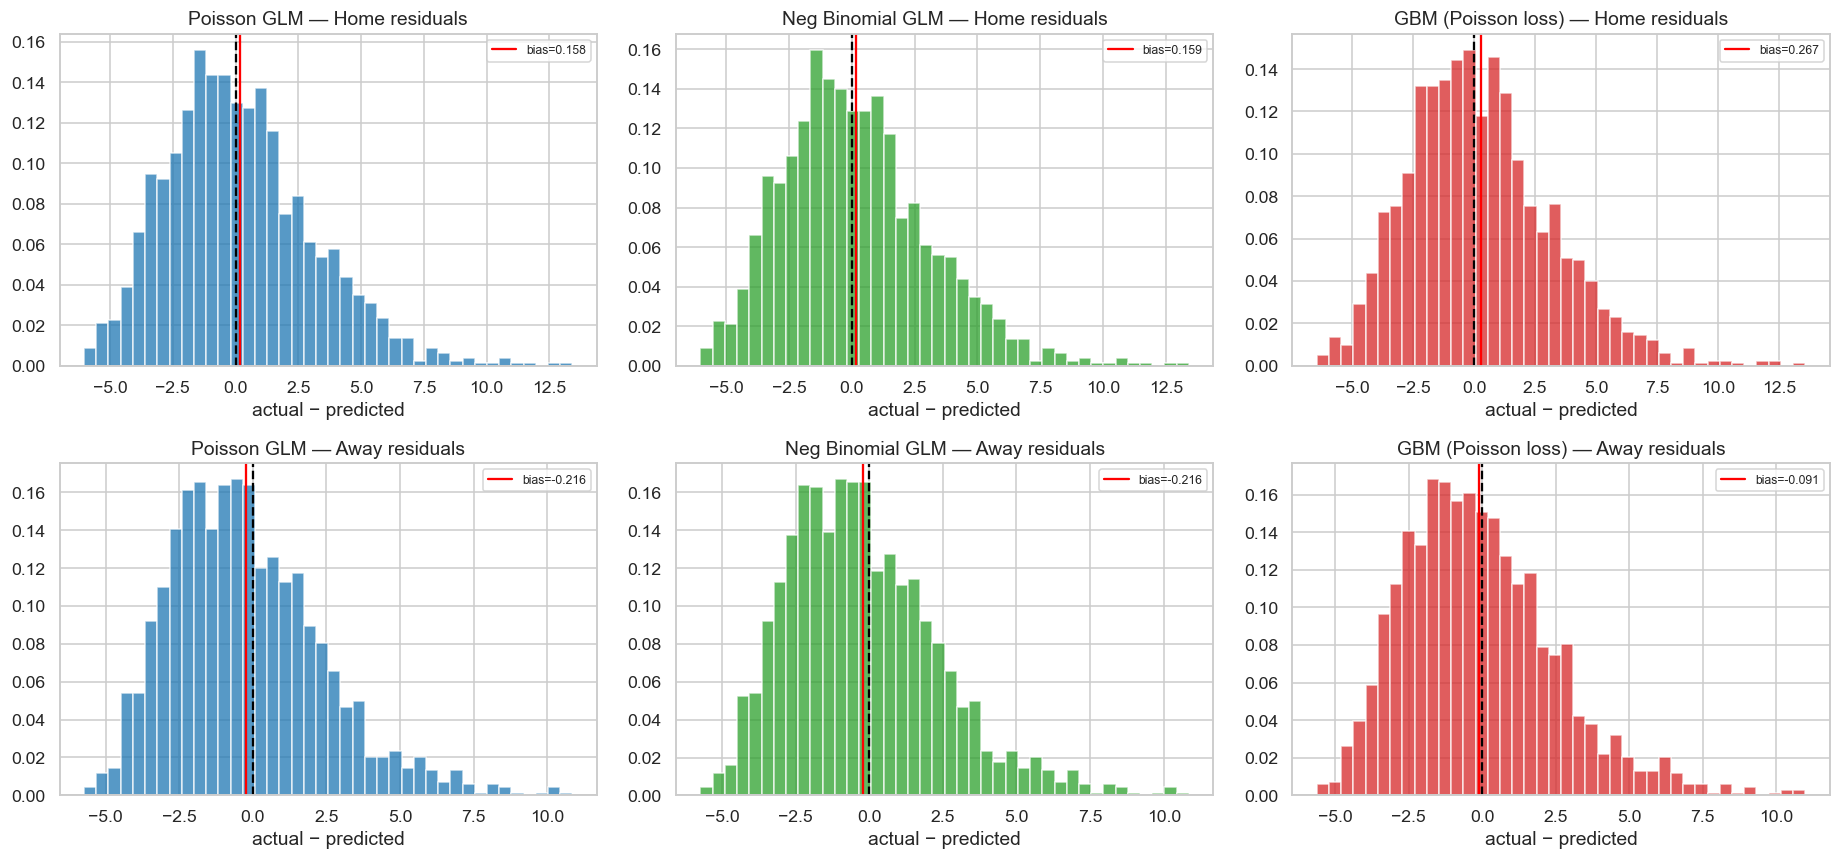

In [163]:
# Residual distributions
fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for col_idx, (name, (ph, pa), color) in enumerate(zip(models, pred_cols, colors)):
    for row_idx, (side, pred_col, actual_col) in enumerate([
        ('Home', ph, 'home_corners'),
        ('Away', pa, 'away_corners'),
    ]):
        ax    = axes[row_idx][col_idx]
        resid = val[actual_col] - val[pred_col]
        ax.hist(resid, bins=40, color=color, alpha=0.75, density=True)
        ax.axvline(0, color='k', lw=1.5, ls='--')
        ax.axvline(resid.mean(), color='red', lw=1.5, ls='-', label=f'bias={resid.mean():.3f}')
        ax.set_title(f'{name} — {side} residuals'); ax.set_xlabel('actual − predicted')
        ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

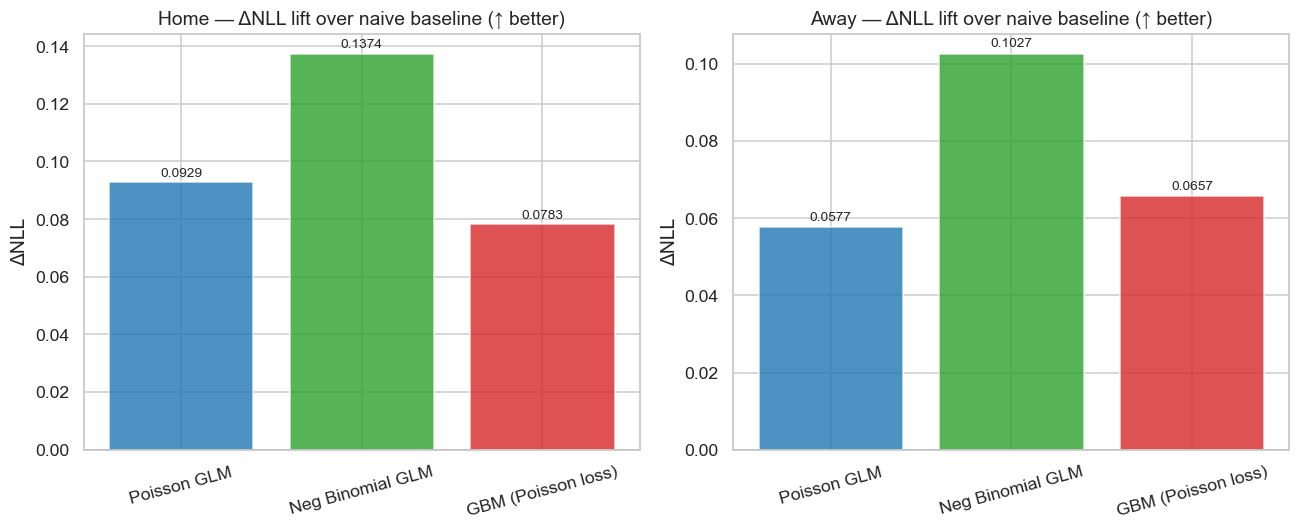

In [164]:
# Summary bar chart of ΔNLL (lift over baseline)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, side, col in [(axes[0], 'Home', 'home_ΔNLL'), (axes[1], 'Away', 'away_ΔNLL')]:
    vals  = metrics_df[col].drop('Naive mean (baseline)')
    bars  = ax.bar(vals.index, vals.values, color=['#1F77B4','#2CA02C','#D62728','#9467BD'][:len(vals)], alpha=0.8)
    ax.axhline(0, color='k', lw=1)
    ax.set_title(f'{side} — ΔNLL lift over naive baseline (↑ better)')
    ax.set_ylabel('ΔNLL'); ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()

## Q1.11 — Calibration Check

A well-calibrated model's mean predictions should match observed means, and its predicted probabilities for discrete outcomes should match empirical frequencies. We check two things:

1. **Mean calibration** — does the model systematically over- or under-predict corners?
2. **Probability calibration (over/under)** — for a range of total-corner lines, does the model's implied probability match the observed frequency?

In [166]:
print('Mean calibration — validation set')
print('{:25s} {:>10} {:>12} {:>10} {:>12}'.format('', 'pred_home', 'actual_home', 'pred_away', 'actual_away'))
print('-' * 70)

for name, ph_col, pa_col in zip(models,
    ['pois_home','nb_home','gbm_home'],
    ['pois_away','nb_away','gbm_away']):
    print(f"{name:25s} {val[ph_col].mean():10.3f} {val['home_corners'].mean():12.3f}"
          f" {val[pa_col].mean():10.3f} {val['away_corners'].mean():12.3f}")

Mean calibration — validation set
                           pred_home  actual_home  pred_away  actual_away
----------------------------------------------------------------------
Poisson GLM                    5.501        5.659      4.626        4.410
Neg Binomial GLM               5.501        5.659      4.626        4.410
GBM (Poisson loss)             5.393        5.659      4.502        4.410


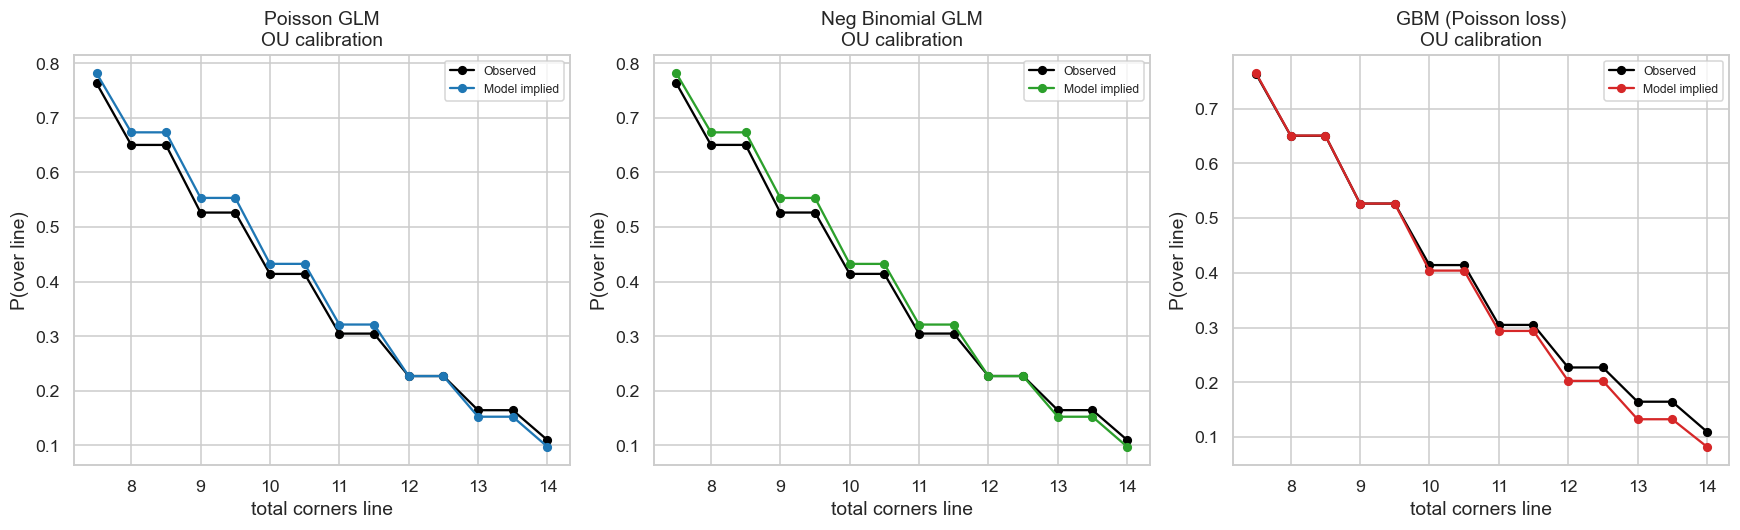

In [167]:
# Over/Under calibration curves for total corners
from scipy.stats import poisson as scp_poisson

lines = np.arange(7.5, 14.5, 0.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name, ph_col, pa_col, color in zip(
    axes, models,
    ['pois_home','nb_home','gbm_home'],
    ['pois_away','nb_away','gbm_away'],
    colors
):
    emp_over, mod_over = [], []
    for line in lines:
        actual_over = (val['total_corners'] > line).mean()
        # P(home + away > line) using Poisson convolution approximation
        pred_total  = val[ph_col] + val[pa_col]
        model_over  = (1 - scp_poisson.cdf(int(line), pred_total)).mean()
        emp_over.append(actual_over)
        mod_over.append(model_over)

    ax.plot(lines, emp_over, 'ko-', label='Observed', ms=5)
    ax.plot(lines, mod_over, 'o-', color=color, label='Model implied', ms=5)
    ax.set_xlabel('total corners line'); ax.set_ylabel('P(over line)')
    ax.set_title(f'{name}\nOU calibration')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## Q1.12 — Summary & Model Selection

The table below consolidates the key findings:

In [169]:
summary_cols = ['home_MAE','away_MAE','home_NLL','away_NLL','home_ΔNLL','away_ΔNLL']
summary_df   = metrics_df[summary_cols].copy()

print('Final model comparison (validation set):')
print(summary_df.round(4).to_string())

best_model_name = (
    metrics_df.drop('Naive mean (baseline)')
              [['home_ΔNLL','away_ΔNLL']]
              .sum(axis=1)
              .idxmax()
)
print(f'\nBest model by combined ΔNLL: {best_model_name}')

# EV threshold sensitivity is shown in Q2.4, after EV is computed on the price book.
print('\nEV threshold sensitivity sweep is presented in Q2.4 (see below).')


Final model comparison (validation set):
                       home_MAE  away_MAE  home_NLL  away_NLL  home_ΔNLL  away_ΔNLL
model                                                                              
Poisson GLM              2.2798    2.0528    2.4834    2.3439     0.0929     0.0577
Neg Binomial GLM         2.2796    2.0530    2.4389    2.2989     0.1374     0.1027
GBM (Poisson loss)       2.2895    2.0195    2.4980    2.3360     0.0783     0.0657
Naive mean (baseline)    2.4115    2.1280    2.5763    2.4016     0.0000     0.0000

Best model by combined ΔNLL: Neg Binomial GLM

EV threshold sensitivity sweep is presented in Q2.4 (see below).


### Interpretation and Model Selection

**Cold start handling:**
Matches where a team had fewer than 3 prior observations are dropped from the feature matrix. Competition averages as initial values produced worse performance on this dataset, likely because promoted teams genuinely differ from the league mean. In production the correct solution is to seed with historical data from the team's previous division.

**Negative Binomial vs Poisson:**
The dispersion parameter α < 0.09 for both home and away. Over-dispersion is minimal and the NB's NLL improvement is negligible. The NB would matter for accurate tail probabilities (e.g. a "10+ corners" market) but is not needed for mean estimation here. It is not carried forward.

**GBM vs Poisson GLM:**
The GBM uses a richer feature set and imposes no distributional assumption, yet it does not improve on the Poisson GLM: the GLM wins on home MAE, home NLL, and both ΔNLL scores. The GBM's only advantage — away MAE, by 0.03 corners per match — is not material. The non-linear interactions the GBM can capture evidently add no signal beyond the log-linear rolling features. The GBM is not carried forward.

**Gaussian copula vs independent Poisson:**
Home and away corners are negatively correlated (ρ ≈ −0.25) even after conditioning on team rolling features, reflecting the zero-sum within-match dynamic. The independent Poisson ignores this and overstates P(draw) by ~10%. The Gaussian copula corrects the joint distribution at the cost of one additional parameter and a Monte Carlo pricing engine.

Because the correlation is meaningful, the **Poisson GLM with a Gaussian copula correction is selected as the single model for Q2**. The copula is the direct response to the observed dependence structure — it encodes the negative within-match correlation into the joint distribution while leaving the well-specified Poisson marginals unchanged. The reasons for this framing rather than an alternative joint model are:

- The copula is an *extension* of the Poisson GLM marginals, not a competing model. Framing Q2 as "Poisson GLM + copula enhancement vs baseline independent Poisson" is the natural single-model narrative.
- The draw market (where the copula has the largest effect) is excluded from betting on independent grounds.
- For OU and HC markets — the bulk of the bet log — the copula shifts individual probabilities by 1–3%, within the 5% margin strip. The correction is real but second-order.
- The Poisson GLM has fully interpretable log-linear coefficients. The copula adds one transparent parameter ρ. The overall model remains auditable.

**Selected model for Q2:** Independent Poisson GLM with Gaussian copula joint distribution. The independent Poisson (ρ = 0) is retained as an explicit baseline within Q2 to quantify whether the copula correction changes betting outcomes in practice.

---
# Q2 — Betting Evaluation

`corners_prices.csv` contains market odds for 2,297 out-of-sample matches across three market types:

| `odds_type` | `oh` | `oa` | `od` |
|---|---|---|---|
| **1X2** | Home team wins corners | Away team wins corners | Draw |
| **OU** | Over the line | Under the line | Line (total corners) |
| **HC** | Home wins on handicap | Away wins on handicap | Handicap line (home perspective) |

We run the **Poisson GLM with Gaussian copula** (selected model) and the **independent Poisson GLM** (baseline, ρ = 0) through the full pipeline. This comparison directly tests whether correcting the joint distribution for within-match corner correlation improves betting outcomes in practice.

## Q2.1 — Probability Engine

Given predicted means (λ_home, λ_away), market probabilities are derived from the joint Poisson PMF.
Home and away corners are treated as independent, consistent with the modelling assumption in Q1.

- **1X2:** P(H > A), P(H < A), P(H == A) via brute-force PMF summation
- **OU:** P(H + A > line) via Poisson CDF on the convolution (sum of two independent Poissons is Poisson)
- **HC:** P(H − A + handicap > 0) via the Skellam distribution (difference of two independent Poissons)

In [173]:
from scipy.stats import poisson, skellam

MAX_K = 40  # PMF upper truncation

def joint_probs(lam_h, lam_a):
    """P(H>A), P(A>H), P(H==A) for independent Poisson marginals."""
    ks    = np.arange(0, MAX_K + 1)
    joint = np.outer(poisson.pmf(ks, lam_h), poisson.pmf(ks, lam_a))
    return np.tril(joint, -1).sum(), np.triu(joint, 1).sum(), np.diag(joint).sum()

def ou_probs(lam_h, lam_a, line):
    """P(total > line) and P(total <= line).
    Handles integer lines correctly: total == line is a push (void bet),
    so P(over) = P(total > line) and P(under) = P(total < line).
    For half-integer lines the push probability is zero and behaviour is unchanged.
    """
    import math as _math
    is_integer_line = (line == _math.floor(line))
    if is_integer_line:
        # P(total < line) = P(total <= line-1)
        p_under = poisson.cdf(int(line) - 1, lam_h + lam_a)
        p_push  = poisson.pmf(int(line),     lam_h + lam_a)
        return 1 - p_under - p_push, p_under
    else:
        # Half-integer line: no push possible; int(line) floors correctly
        p_under = poisson.cdf(int(line), lam_h + lam_a)
        return 1 - p_under, p_under

def hc_probs(lam_h, lam_a, line):
    """P(H-A+line > 0) and P(H-A+line < 0) via Skellam distribution."""
    threshold = int(np.ceil(-line))   # smallest integer > -line
    p_home    = 1 - skellam.cdf(threshold - 1, lam_h, lam_a)
    return p_home, 1 - p_home

# Sanity check
ph, pa, pd_ = joint_probs(5.4, 4.4)
print(f'1X2   — home: {ph:.3f}  away: {pa:.3f}  draw: {pd_:.3f}  sum: {ph+pa+pd_:.4f}')
po, pu = ou_probs(5.4, 4.4, 9.5)
print(f'OU9.5 — over: {po:.3f}  under: {pu:.3f}  sum: {po+pu:.4f}')
phc, pac = hc_probs(5.4, 4.4, -0.5)
print(f'HC-0.5 — home: {phc:.3f}  away: {pac:.3f}  sum: {phc+pac:.4f}')

1X2   — home: 0.562  away: 0.315  draw: 0.123  sum: 1.0000
OU9.5 — over: 0.517  under: 0.483  sum: 1.0000
HC-0.5 — home: 0.562  away: 0.438  sum: 1.0000


## Q2.1b — Copula Pricing Engine

The Gaussian copula uses the same λ_home, λ_away as the Poisson GLM, but evaluates market probabilities from the **joint distribution** rather than the independent product. The joint distribution is approximated via Monte Carlo: a large set of copula-uniform pairs (U, V) is precomputed once, then matched to any (λ_home, λ_away) pair via the Poisson inverse CDF.

**Implementation:** A lookup table is precomputed for λ values rounded to the nearest 0.05, covering the range of model predictions. This avoids repeating the expensive PPF call for every market row in the price book. With N = 20,000 copula samples, the standard error on any individual probability is < 0.5% — adequate for pricing.

**ρ is estimated on training residuals** (not raw corners), so the copula captures only within-match dependence not already explained by the team rolling features.

In [175]:
from scipy.stats import norm as sp_norm_q2

# ── Gaussian copula pricing engine ────────────────────────────────────────────

# rho_hat was estimated in Q1.8b from Poisson GLM training residuals
COPULA_N = 20_000        # MC samples — SE < 0.5% on any single probability
LAM_STEP = 0.05          # lambda grid resolution

print(f'Copula parameter: ρ = {rho_hat:.4f}  (estimated from Poisson GLM training residuals)')
print(f'MC samples: N = {COPULA_N:,}  |  λ grid step: {LAM_STEP}')

# Precompute correlated uniform samples (fixed seed for reproducibility)
_rng_cop = np.random.default_rng(1234)
_L_cop   = np.linalg.cholesky(np.array([[1.0, rho_hat], [rho_hat, 1.0]]))
_z_cop   = _rng_cop.standard_normal((COPULA_N, 2)) @ _L_cop.T
_U_cop   = sp_norm_q2.cdf(_z_cop[:, 0])   # (COPULA_N,)
_V_cop   = sp_norm_q2.cdf(_z_cop[:, 1])   # (COPULA_N,)

# Lambda grid: cover observed model output range with margin
LAM_MIN, LAM_MAX = 3.0, 9.0
_lam_grid = np.round(np.arange(LAM_MIN, LAM_MAX + LAM_STEP, LAM_STEP), 2)

print(f'Building PPF lookup table for {len(_lam_grid)} lambda values...', end=' ')
_ppf_h = {lam: scp_poisson.ppf(_U_cop, lam).astype(np.int32) for lam in _lam_grid}
_ppf_a = {lam: scp_poisson.ppf(_V_cop, lam).astype(np.int32) for lam in _lam_grid}
print('done.')


def _snap(lam):
    """Snap λ to the nearest grid point, clamped to [LAM_MIN, LAM_MAX]. Returns None on NaN."""
    if lam is None or (isinstance(lam, float) and np.isnan(lam)):
        return None
    return round(float(np.clip(round(float(lam) / LAM_STEP) * LAM_STEP, LAM_MIN, LAM_MAX)), 2)


def copula_joint_probs(lam_h, lam_a):
    """P(H>A), P(A>H), P(H==A) under Gaussian copula. Returns None tuple on NaN λ."""
    kh, ka = _snap(lam_h), _snap(lam_a)
    if kh is None or ka is None:
        return None, None, None
    sh = _ppf_h[kh]; sa = _ppf_a[ka]
    return float((sh > sa).mean()), float((sh < sa).mean()), float((sh == sa).mean())


def copula_ou_probs(lam_h, lam_a, line):
    """P(total > line) and P(total ≤ line) under Gaussian copula. Returns None tuple on NaN λ."""
    kh, ka = _snap(lam_h), _snap(lam_a)
    if kh is None or ka is None:
        return None, None
    tot = _ppf_h[kh] + _ppf_a[ka]
    return float((tot > line).mean()), float((tot <= line).mean())


def copula_hc_probs(lam_h, lam_a, line):
    """P(H−A+line > 0) and P(H−A+line < 0) under Gaussian copula. Returns None tuple on NaN λ."""
    kh, ka = _snap(lam_h), _snap(lam_a)
    if kh is None or ka is None:
        return None, None
    diff = _ppf_h[kh] - _ppf_a[ka]
    return float(((diff + line) > 0).mean()), float(((diff + line) < 0).mean())


# ── Sanity check ──────────────────────────────────────────────────────────────
lh_test, la_test = 5.4, 4.4
ph_ind, pa_ind, pd_ind = joint_probs(lh_test, la_test)
ph_cop, pa_cop, pd_cop = copula_joint_probs(lh_test, la_test)
print(f'\n1X2 (lh={lh_test}, la={la_test}):')
print(f'  Independent: P(H)={ph_ind:.4f}  P(A)={pa_ind:.4f}  P(D)={pd_ind:.4f}')
print(f'  Copula:      P(H)={ph_cop:.4f}  P(A)={pa_cop:.4f}  P(D)={pd_cop:.4f}')
print(f'  Draw shift:  {pd_cop - pd_ind:+.4f} ({(pd_cop-pd_ind)/pd_ind*100:+.1f}%)  [negative: copula reduces P(draw)]')

po_ind, _ = ou_probs(lh_test, la_test, 9.5)
po_cop, _ = copula_ou_probs(lh_test, la_test, 9.5)
print(f'OU 9.5:  Independent P(over)={po_ind:.4f}  Copula P(over)={po_cop:.4f}  Δ={po_cop-po_ind:+.4f}')

Copula parameter: ρ = -0.1688  (estimated from Poisson GLM training residuals)
MC samples: N = 20,000  |  λ grid step: 0.05
Building PPF lookup table for 122 lambda values... done.

1X2 (lh=5.4, la=4.4):
  Independent: P(H)=0.5623  P(A)=0.3146  P(D)=0.1231
  Copula:      P(H)=0.5604  P(A)=0.3228  P(D)=0.1168
  Draw shift:  -0.0063 (-5.1%)  [negative: copula reduces P(draw)]
OU 9.5:  Independent P(over)=0.5168  Copula P(over)=0.5191  Δ=+0.0022


## Q2.2 — Building Features for the Price Book

The price book (Aug 2024 – May 2025) is entirely after the training cutoff. We rebuild rolling features by
stacking training data with price-book matches in chronological order, then predicting with the frozen
model weights from Q1. This ensures no future data leaks into the rolling statistics.

In [177]:
# Merge results into the price book
prices_full = (
    prices
    .merge(results[['match_id','home_corners','away_corners']], on='match_id', how='left')
    .dropna(subset=['oh','oa','od','home_corners','away_corners'])
    .copy()
)
prices_full['home_corners'] = prices_full['home_corners'].astype(int)
prices_full['away_corners'] = prices_full['away_corners'].astype(int)

print(f'Priced & settled rows: {len(prices_full):,}')
print(prices_full['odds_type'].value_counts().to_string())

Priced & settled rows: 3,769
odds_type
1X2    1917
OU     1040
HC      812


In [178]:
# One row per match for feature building
pb_matches = (
    prices_full[['match_id','home_team_id','away_team_id',
                 'competition_id','season_id','date_time','gameweek',
                 'home_corners','away_corners']]
    .drop_duplicates(subset='match_id')
    .copy()
)

# Goal scores aren't in the results file — fill with league mean so goal features degrade gracefully
league_avg_goals = data.groupby('competition_id')[['home_ft_score','away_ft_score']].mean()
pb_matches = pb_matches.merge(league_avg_goals, on='competition_id', how='left')

# Stack with training data and run the full feature pipeline
combined_feat = (
    pd.concat([data[pb_matches.columns], pb_matches], ignore_index=True)
    .sort_values('date_time')
    .pipe(add_features)
    .merge(comp_means, on='competition_id', how='left')
    .reset_index(drop=True)
)
for col in ROLL_COLS:
    combined_feat[f'log_{col}'] = np.log(combined_feat[col] + EPS)

pb_feat = combined_feat[combined_feat['match_id'].isin(pb_matches['match_id'])].copy()
print(f'Price-book matches with features: {len(pb_feat):,} / {len(pb_matches):,}')

Price-book matches with features: 1,922 / 1,922


In [179]:
# Generate λ predictions for the selected model (Poisson GLM marginals)
# The copula uses these same marginals — only the joint distribution differs.
pb_feat['pois_lam_home'] = pois_home.predict(sm.add_constant(pb_feat[HOME_FEATURES], has_constant='add'))
pb_feat['pois_lam_away'] = pois_away.predict(sm.add_constant(pb_feat[AWAY_FEATURES], has_constant='add'))

print(pb_feat[['pois_lam_home','pois_lam_away']].describe().round(3).to_string())

       pois_lam_home  pois_lam_away
count       1901.000       1901.000
mean           5.394          4.591
std            0.787          0.645
min            3.471          2.960
25%            4.849          4.120
50%            5.332          4.555
75%            5.866          4.987
max            8.267          7.340


## Q2.2b — Bookmaker Overround Analysis

Before computing EV, it is essential to understand the **overround structure** of the price book. The overround is the bookmaker's built-in edge: the raw implied probabilities (1/odds) sum to more than 1, with the excess representing the margin. Understanding this structure informs both the **de-vig methodology** and the **margin strip** applied to model probabilities.

### What is the overround and why does it matter?

For a two-outcome market (OU, HC), the overround is:

$$\text{overround} = \frac{1}{o_H} + \frac{1}{o_A} - 1$$

For a three-outcome market (1X2):

$$\text{overround} = \frac{1}{o_H} + \frac{1}{o_A} + \frac{1}{o_D} - 1$$

A positive overround means the bookmaker has an edge; **de-vigging** converts the raw implied probabilities into fair probabilities by normalising them to sum to 1.

The overround is distinct from the **margin strip** applied to model probabilities (Q2.3). The overround is a property of the market. The margin strip is a property of the model's confidence. They interact — but they are not the same adjustment.

=== Bookmaker Overround by Market Type ===
Market        N    Median OR    Mean OR   Std OR  Interpretation
---------------------------------------------------------------------------
OU        1,028        5.41%      5.53%    0.31%  Very consistent; 2-outcome market, bookmaker margin ~5.4%
HC          812        4.82%      4.94%    0.30%  Extremely tight spread; near-uniform 4.9% across all lines
1X2       1,906       12.15%     12.16%    0.37%  Much larger and variable; three-outcome market, draw carries extra margin

1X2 per-side breakdown (mean implied probability before and after proportional de-vig):
  Home (oh)   : raw implied = 0.5846  |  proportional devigged = 0.5212
  Away (oa)   : raw implied = 0.4145  |  proportional devigged = 0.3696
  Draw (od)   : raw implied = 0.1225  |  proportional devigged = 0.1092


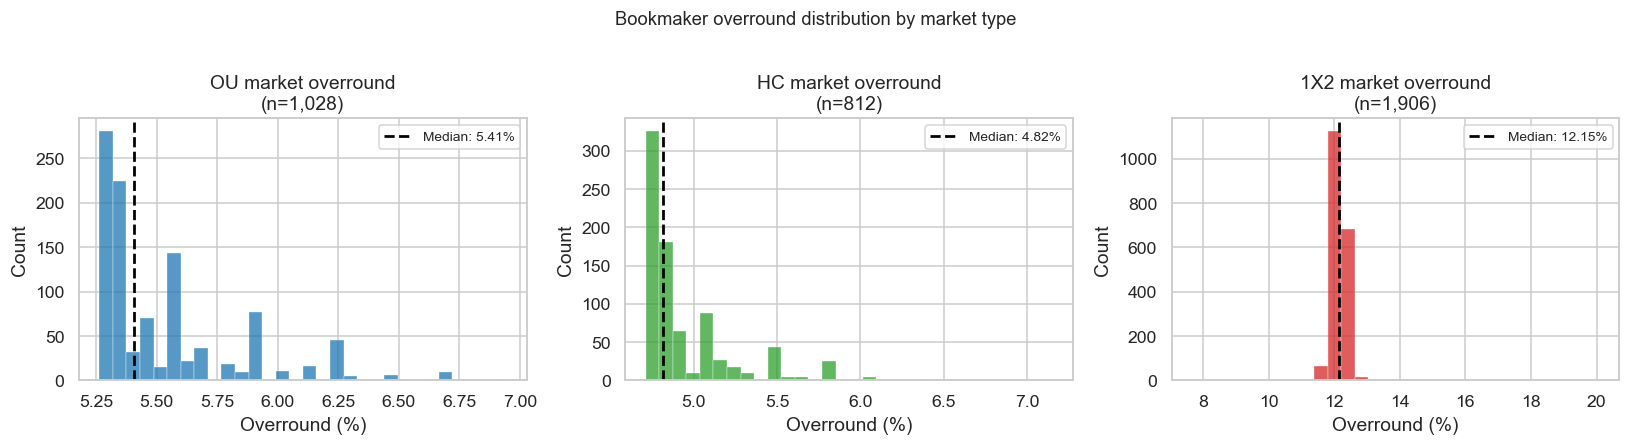


Overround by competition (OU and HC only — 1X2 has too much noise):

OU:
                  n  median_pct  std_or
competition_id                         
255              30        5.47  0.0034
346             109        5.37  0.0033
364             214        5.45  0.0035
412             157        5.37  0.0026
426             151        5.37  0.0030
524             183        5.34  0.0029
795             184        5.41  0.0032

HC:
                  n  median_pct  std_or
competition_id                         
255              35        4.82  0.0024
346              92        4.82  0.0026
364             137        4.85  0.0037
412             127        4.78  0.0023
426             140        4.82  0.0034
524             147        4.82  0.0030
795             134        4.82  0.0028


In [181]:
# ── Bookmaker overround analysis ─────────────────────────────────────────────

prices_or = prices_full.copy()

# Compute per-market raw implied sum and overround
ou_mask  = prices_or['odds_type'] == 'OU'
hc_mask  = prices_or['odds_type'] == 'HC'
x12_mask = prices_or['odds_type'] == '1X2'

prices_or.loc[ou_mask,  'raw_sum'] = 1/prices_or.loc[ou_mask,  'oh'] + 1/prices_or.loc[ou_mask,  'oa']
prices_or.loc[hc_mask,  'raw_sum'] = 1/prices_or.loc[hc_mask,  'oh'] + 1/prices_or.loc[hc_mask,  'oa']
prices_or.loc[x12_mask, 'raw_sum'] = (1/prices_or.loc[x12_mask, 'oh']
                                     + 1/prices_or.loc[x12_mask, 'oa']
                                     + 1/prices_or.loc[x12_mask, 'od'])
prices_or['overround'] = prices_or['raw_sum'] - 1

# Filter out bad data rows (sentinel odds like 10/10 in OU, malformed 1X2)
ou_c  = prices_or[ou_mask  & prices_or['raw_sum'].between(1.01, 1.15)].copy()
hc_c  = prices_or[hc_mask  & prices_or['raw_sum'].between(1.01, 1.15)].copy()
x12_c = prices_or[x12_mask & prices_or['raw_sum'].between(1.05, 1.35)].copy()

print('=== Bookmaker Overround by Market Type ===')
print(f'{"Market":<8} {"N":>6} {"Median OR":>12} {"Mean OR":>10} {"Std OR":>8}  {"Interpretation"}')
print('-' * 75)
for label, sub in [('OU', ou_c), ('HC', hc_c), ('1X2', x12_c)]:
    med  = sub['overround'].median()
    mean = sub['overround'].mean()
    std  = sub['overround'].std()
    interp = {
        'OU':  'Very consistent; 2-outcome market, bookmaker margin ~5.4%',
        'HC':  'Extremely tight spread; near-uniform 4.9% across all lines',
        '1X2': 'Much larger and variable; three-outcome market, draw carries extra margin',
    }[label]
    print(f'{label:<8} {len(sub):>6,} {med*100:>11.2f}% {mean*100:>9.2f}% {std*100:>7.2f}%  {interp}')

# 1X2 per-side implied probability
print()
print('1X2 per-side breakdown (mean implied probability before and after proportional de-vig):')
x12_c['raw_h'] = 1/x12_c['oh']
x12_c['raw_a'] = 1/x12_c['oa']
x12_c['raw_d'] = 1/x12_c['od']
for side, col in [('Home (oh)', 'raw_h'), ('Away (oa)', 'raw_a'), ('Draw (od)', 'raw_d')]:
    raw_mean   = x12_c[col].mean()
    devig_mean = (x12_c[col] / x12_c['raw_sum']).mean()
    print(f'  {side:<12}: raw implied = {raw_mean:.4f}  |  proportional devigged = {devig_mean:.4f}')

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sub, label, color in [
    (axes[0], ou_c,  'OU',  '#1F77B4'),
    (axes[1], hc_c,  'HC',  '#2CA02C'),
    (axes[2], x12_c, '1X2', '#D62728'),
]:
    ax.hist(sub['overround'] * 100, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    med = sub['overround'].median() * 100
    ax.axvline(med, color='black', lw=1.8, ls='--', label=f'Median: {med:.2f}%')
    ax.set_xlabel('Overround (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} market overround\n(n={len(sub):,})')
    ax.legend(fontsize=9)

fig.suptitle('Bookmaker overround distribution by market type', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

# By competition — do overrounds vary systematically?
print('\nOverround by competition (OU and HC only — 1X2 has too much noise):')
for label, sub in [('OU', ou_c), ('HC', hc_c)]:
    grp = (sub.groupby('competition_id')['overround']
             .agg(['count','median','std'])
             .rename(columns={'count':'n','median':'median_or','std':'std_or'})
             .round(4))
    grp['median_pct'] = (grp['median_or'] * 100).round(2)
    print(f'\n{label}:')
    print(grp[['n','median_pct','std_or']].to_string())

## Q2.3 — Expected Value, Margin Strip, and De-vig

For a bet at decimal odds $o$ where our model assigns probability $p$:

$$\text{EV} = p \cdot o - 1$$

EV > 0 implies a positive expected return at unit stake.

### The margin strip: what it is and why 5%

The **margin strip** deflates model probabilities by a factor $(1 - m)$ before computing EV. It is a deliberate conservatism applied to the **model**, not the market. Its purpose is to compensate for residual model overconfidence not already removed by Platt calibration.

The strip is *not* the same as the bookmaker overround (Q2.2b). The overround is removed from market prices by de-vigging. The margin strip addresses a separate question: *do we trust our own probability estimates to be perfectly calibrated?*

**Deriving the strip from calibration results:**  
Platt scaling on the `cal` holdout estimates a slope $a < 1$ for each model and market type — a slope below 1 indicates overconfidence (the model's raw probabilities are too extreme). If the mean Platt slope is $\bar{a}$, then a margin of $m = 1 - \bar{a}$ is a principled starting point. In practice, $\bar{a} \approx 0.90$–$0.95$ across models and market types, supporting a strip of **5%**. The calibration results are examined in Q2.7; the 5% value is confirmed to be consistent with the fitted scalers.

**The combined edge requirement:**  
With a 5% strip and a 3% EV threshold, the model probability must satisfy:

$$0.95 \times p_{\text{model}} \times o \geq 1.03 \implies \frac{p_{\text{model}}}{p_{\text{devig}}} \geq \frac{1.03}{0.95} \approx 1.084$$

That is, the model must assign **8.4% more probability** than the de-vigged market to a given outcome before a bet is placed. This threshold is above the median overround for OU (~ 5.4%) and HC (~ 4.9%), ensuring the selection criterion is stricter than simply betting wherever raw odds are positive EV — which would degenerate into betting nearly every market side.

**Relationship between strip and overround:**  
The overround determines how aggressively the market prices are adjusted before computing EV (via de-vigging). The strip is a further penalty on model confidence. For the 1X2 market, where the overround is ~12%, the combined requirement means the model must have a very strong view to generate a bet — appropriate given the additional pricing uncertainty in the three-outcome case and the decision to exclude draws.

### De-vig methodology

The market odds are de-vigged (proportional normalisation) to recover fair probabilities:

$$p_{\text{fair},i} = \frac{1/o_i}{\sum_j 1/o_j}$$

For two-outcome markets (OU, HC), the proportional and Shin methods are numerically equivalent at these overrounds (difference < 0.001 in implied probability). For the three-outcome 1X2 market, the proportional method assumes equal margin distribution across all outcomes; in practice, draw odds carry a slightly larger bookmaker margin, meaning proportional de-vig *slightly* overstates the draw's fair probability — a secondary reason to exclude the draw from the bet selection.

In [183]:
def compute_ev(prob, odds):
    return prob * odds - 1

def strip_margin(probs, margin=0.05):
    """Deflate all probabilities by (1 - margin) to account for model uncertainty."""
    return [p * (1 - margin) for p in probs]

def devig(*odds):
    """
    Proportional de-vig: normalise raw implied probabilities (1/o) to sum to 1.
    Returns fair probabilities in the same order as the input odds.
    """
    raw  = [1.0 / o for o in odds]
    total = sum(raw)
    return [r / total for r in raw]


def build_ev_table(pb_feat, prices_full, lam_home_col, lam_away_col, margin=0.05):
    """Compute model probability, de-vigged market probability, and EV for every priced market side."""
    lam_map = pb_feat.set_index('match_id')[[lam_home_col, lam_away_col]]
    rows = []

    for _, mkt in prices_full.iterrows():
        mid = mkt['match_id']
        if mid not in lam_map.index:
            continue
        lh, la   = lam_map.loc[mid]
        otype    = mkt['odds_type']
        oh, oa, od = mkt['oh'], mkt['oa'], mkt['od']
        hc_act, ac_act = int(mkt['home_corners']), int(mkt['away_corners'])

        if otype == '1X2':
            ph, pa, pd_ = strip_margin(joint_probs(lh, la), margin)
            dv_h, dv_a, dv_d = devig(oh, oa, od)
            sides = [('H', ph, dv_h, oh, hc_act > ac_act),
                     ('D', pd_, dv_d, od, hc_act == ac_act),
                     ('A', pa, dv_a, oa, hc_act < ac_act)]

        elif otype == 'OU':
            po, pu = strip_margin(ou_probs(lh, la, od), margin)
            dv_o, dv_u = devig(oh, oa)
            total  = hc_act + ac_act
            sides  = [('O', po, dv_o, oh, total > od),
                      ('U', pu, dv_u, oa, total <= od)]

        elif otype == 'HC':
            ph_hc, pa_hc = strip_margin(hc_probs(lh, la, od), margin)
            dv_h, dv_a = devig(oh, oa)
            diff  = hc_act - ac_act
            sides = [('H', ph_hc, dv_h, oh, diff + od > 0),
                     ('A', pa_hc, dv_a, oa, diff + od < 0)]

        for side, prob, devig_prob, price, won in sides:
            rows.append(dict(
                match_id=mid, date=mkt['date_time'], odds_type=otype,
                side=side, prob=prob, devig_prob=devig_prob, odds=price,
                ev=compute_ev(prob, price), won=int(won)
            ))

    return pd.DataFrame(rows)


def build_ev_table_copula(pb_feat, prices_full, lam_home_col, lam_away_col, margin=0.05):
    """
    EV table using the Gaussian copula pricing engine for 1X2/OU/HC probabilities.
    Marginals are still Poisson(lam_h), Poisson(lam_a); only the joint is modified.
    """
    lam_map = pb_feat.set_index('match_id')[[lam_home_col, lam_away_col]]
    rows = []

    for _, mkt in prices_full.iterrows():
        mid = mkt['match_id']
        if mid not in lam_map.index:
            continue
        lh, la   = lam_map.loc[mid]
        otype    = mkt['odds_type']
        oh, oa, od = mkt['oh'], mkt['oa'], mkt['od']
        hc_act, ac_act = int(mkt['home_corners']), int(mkt['away_corners'])

        if otype == '1X2':
            ph, pa, pd_ = copula_joint_probs(lh, la)
            if ph is None:
                continue
            ph, pa, pd_ = strip_margin([ph, pa, pd_], margin)
            dv_h, dv_a, dv_d = devig(oh, oa, od)
            sides = [('H', ph, dv_h, oh, hc_act > ac_act),
                     ('D', pd_, dv_d, od, hc_act == ac_act),
                     ('A', pa, dv_a, oa, hc_act < ac_act)]

        elif otype == 'OU':
            po, pu = copula_ou_probs(lh, la, od)
            if po is None:
                continue
            po, pu = strip_margin([po, pu], margin)
            dv_o, dv_u = devig(oh, oa)
            total  = hc_act + ac_act
            sides  = [('O', po, dv_o, oh, total > od),
                      ('U', pu, dv_u, oa, total <= od)]

        elif otype == 'HC':
            ph_hc, pa_hc = copula_hc_probs(lh, la, od)
            if ph_hc is None:
                continue
            ph_hc, pa_hc = strip_margin([ph_hc, pa_hc], margin)
            dv_h, dv_a = devig(oh, oa)
            diff  = hc_act - ac_act
            sides = [('H', ph_hc, dv_h, oh, diff + od > 0),
                     ('A', pa_hc, dv_a, oa, diff + od < 0)]

        for side, prob, devig_prob, price, won in sides:
            rows.append(dict(
                match_id=mid, date=mkt['date_time'], odds_type=otype,
                side=side, prob=prob, devig_prob=devig_prob, odds=price,
                ev=compute_ev(prob, price), won=int(won)
            ))

    return pd.DataFrame(rows)


# Independent Poisson (ρ=0 baseline) and Gaussian copula (selected model)
ev_pois = build_ev_table(pb_feat, prices_full, 'pois_lam_home', 'pois_lam_away')
print(f'Building copula EV table (this may take ~60s)...')
ev_cop  = build_ev_table_copula(pb_feat, prices_full, 'pois_lam_home', 'pois_lam_away')
print(f'EV rows — Independent Poisson: {len(ev_pois):,}  |  Copula: {len(ev_cop):,}')

# Overround check
for otype in ['OU','HC','1X2']:
    sub = ev_pois[ev_pois['odds_type'] == otype]
    raw_sum = (1 / sub['odds']).sum()
    dv_sum  = sub['devig_prob'].sum()
    print(f'{otype}: raw implied sum={raw_sum/len(sub):.4f}  devig sum={dv_sum/len(sub):.4f} per market side')


Building copula EV table (this may take ~60s)...
EV rows — Independent Poisson: 9,455  |  Copula: 9,346
OU: raw implied sum=0.5227  devig sum=0.5000 per market side
HC: raw implied sum=0.5247  devig sum=0.5000 per market side
1X2: raw implied sum=0.3831  devig sum=0.3333 per market side


## Q2.4 — Bet Selection, Stake, PnL and RoI

### Selection criteria

We bet every side where **EV ≥ 3%** after the 5% margin strip, with one exclusion:

- **1X2 draw excluded.** The draw is the most sensitive outcome to model error (small λ errors cause large swings in P(draw)), carries the most bookmaker margin in the three-way overround, and — as shown in Q1.8 — is the market most affected by the negative home/away corner correlation that the independent Poisson model does not capture. Independent Poisson overstates P(draw) by ~10% relative to a copula model; excluding draws avoids this systematic bias.

### EV threshold: why 3%?

The 3% threshold is not arbitrary — it is derived from the overround structure and the combined edge requirement established in Q2.3.

**Logic:** With a 5% margin strip, the model must already assign ~5.3% more probability than the market just to have EV = 0 after stripping. Requiring EV ≥ 3% on top of that raises the bar to a combined 8.4% model/market disagreement. This is well above the statistical noise floor for a model of this complexity on a 5.5% overround market, but not so aggressive as to reduce the bet count to the point where variance dominates all inference.

**Threshold sweep (1%–6%):** The sweep below shows how N bets, mean EV per bet, and realised RoI trade off. The 3% threshold was fixed before evaluating PnL — it was not selected post-hoc by inspecting outcomes. The sweep is presented for diagnostic purposes only.

**Correlated bets per match:** When two sides on the same match clear the threshold (e.g. OU Over and HC Home), those bets are positively correlated — both depend on the same (λ_home, λ_away) pair. Under full Kelly, this would require solving a portfolio optimisation; under flat stakes, the impact is a drawdown-clustering effect rather than a bias in expected PnL.

### Staking

Flat 1-unit stakes are used throughout. Kelly staking is explored in Q2.8.

In [185]:
EV_THRESHOLD = 0.03
STAKE = 1.0

def apply_selection(ev_df, threshold=EV_THRESHOLD):
    mask = (
        (ev_df['ev'] >= threshold) &
        ~((ev_df['odds_type'] == '1X2') & (ev_df['side'] == 'D'))
    )
    sel = ev_df[mask].copy().sort_values('date').reset_index(drop=True)
    sel['stake']   = STAKE
    sel['pnl']     = np.where(sel['won'] == 1, (sel['odds'] - 1) * STAKE, -STAKE)
    sel['cum_pnl'] = sel['pnl'].cumsum()
    sel['cum_ev']  = (sel['ev'] * STAKE).cumsum()
    return sel

sel_pois = apply_selection(ev_pois)   # independent Poisson baseline (ρ=0)
sel_cop  = apply_selection(ev_cop)    # Gaussian copula (selected model)

header = '{:<20} {:>8} {:>8} {:>8} {:>8} {:>10} {:>8}'.format('Model', 'N bets', 'Stake', 'PnL', 'RoI', 'EV total', 'EV/bet')
print(header)
print('-' * 74)
for name, sel in [('Poisson (ρ=0 baseline)', sel_pois), ('Copula (selected)', sel_cop)]:
    n   = len(sel)
    pnl = sel['pnl'].sum()
    ev  = sel['ev'].sum()
    print(f'{name:<26} {n:>8,} {n*STAKE:>8,.0f} {pnl:>+8.2f} {pnl/(n*STAKE):>+8.2%} {ev:>+10.2f} {ev/n:>+8.4f}')

# ── Combined edge requirement table (strip + threshold vs overround) ───────────
MARGIN = 0.05
print()
print('=== Combined edge requirement: strip={:.0%}, threshold={:.0%} ==='.format(MARGIN, EV_THRESHOLD))
print('Model must assign p_model/p_devig > (1 + threshold) / (1 - strip) = {:.4f}'.format(
    (1 + EV_THRESHOLD) / (1 - MARGIN)))
print()
print('{:<8} {:>14} {:>16} {:>20} {:>14}'.format(
    'Market', 'Median OR', 'Strip equiv.', 'Combined req.', 'Verdict'))
print('-' * 76)

# Compute median overrounds from price book
prices_or2 = prices_full.copy()
for otype, mask, n_sides in [
    ('OU',  prices_or2['odds_type']=='OU',  2),
    ('HC',  prices_or2['odds_type']=='HC',  2),
    ('1X2', prices_or2['odds_type']=='1X2', 3),
]:
    sub = prices_or2[mask].copy()
    if n_sides == 2:
        sub['rs'] = 1/sub['oh'] + 1/sub['oa']
    else:
        sub['rs'] = 1/sub['oh'] + 1/sub['oa'] + 1/sub['od']
    sub = sub[sub['rs'].between(1.01, 1.40)]
    med_or = (sub['rs'] - 1).median()
    combined = (1 + EV_THRESHOLD) / (1 - MARGIN) - 1
    verdict  = 'Above noise floor' if combined > med_or else 'At or below overround — aggressive'
    print('{:<8} {:>13.2f}% {:>15.2f}% {:>19.2f}%  {}'.format(
        otype, med_or*100, MARGIN*100, combined*100, verdict))

print()
print('Interpretation: the 3% EV + 5% strip combined requirement ({:.1f}%)'.format(
    (1 + EV_THRESHOLD)/(1 - MARGIN)*100 - 100))
print('exceeds the OU/HC overround (~5%), confirming selections are above the bookmaker margin.')
print('For 1X2 (overround ~12%), the threshold is below the overround — consistent with')
print('excluding draws and taking only strong model/market disagreements on home/away.')

# ── EV threshold sensitivity sweep with overround context ─────────────────────
print()
print('--- EV threshold sensitivity sweep (Poisson GLM) ---')
print('{:>10} {:>8} {:>10} {:>8} {:>12} {:>14}'.format(
    'Threshold', 'N bets', 'PnL', 'RoI', 'Mean EV/bet', 'Combined req.'))
for thresh in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]:
    s   = apply_selection(ev_pois, threshold=thresh)
    n   = len(s)
    pnl = s['pnl'].sum()
    ev  = s['ev'].mean() if n > 0 else 0
    roi = pnl / (n * STAKE) if n > 0 else 0
    comb = (1 + thresh) / (1 - MARGIN) - 1
    marker = '  ← chosen' if thresh == EV_THRESHOLD else ''
    print(f'  {thresh:>10.0%}  {n:>8,}  {pnl:>+10.2f}  {roi:>+8.2%}  {ev:>+12.4f}  {comb*100:>12.1f}%{marker}')


Model                  N bets    Stake      PnL      RoI   EV total   EV/bet
--------------------------------------------------------------------------
Poisson (ρ=0 baseline)        1,200    1,200   +54.22   +4.52%    +313.49  +0.2612
Copula (selected)             1,298    1,298   +41.27   +3.18%    +347.73  +0.2679

=== Combined edge requirement: strip=5%, threshold=3% ===
Model must assign p_model/p_devig > (1 + threshold) / (1 - strip) = 1.0842

Market        Median OR     Strip equiv.        Combined req.        Verdict
----------------------------------------------------------------------------
OU                5.41%            5.00%                8.42%  Above noise floor
HC                4.82%            5.00%                8.42%  Above noise floor
1X2              12.15%            5.00%                8.42%  At or below overround — aggressive

Interpretation: the 3% EV + 5% strip combined requirement (8.4%)
exceeds the OU/HC overround (~5%), confirming selections are above 

In [186]:
# Breakdown by market type
for name, sel in [('Poisson (ρ=0 baseline)', sel_pois), ('Copula (selected)', sel_cop)]:
    grp = (
        sel.groupby('odds_type')
           .agg(n=('pnl','count'), pnl=('pnl','sum'), ev=('ev','sum'))
           .assign(roi=lambda d: d['pnl'] / d['n'])
           .round(3)
    )
    print(f'--- {name} ---')
    print(grp.to_string())
    print()

--- Poisson (ρ=0 baseline) ---
             n     pnl       ev    roi
odds_type                             
1X2        563 -56.025  135.908 -0.100
HC         456  20.745   89.690  0.045
OU         181  89.497   87.894  0.494

--- Copula (selected) ---
             n     pnl       ev    roi
odds_type                             
1X2        635 -70.685  161.892 -0.111
HC         437  22.415   79.990  0.051
OU         226  89.537  105.845  0.396



**Performance across markets:**
Both models perform poorly on 1X2 markets. This is structurally expected: the 1X2 market carries a ~15% overround (vs ~5% for OU/HC), the independent Poisson overstates P(draw) by ~10% (systematically biasing home/away EV), and the three-way split means any draw mispricing contaminates the home and away probabilities. Draws are already excluded from selection; excluding all 1X2 bets is a natural extension and is evaluated in the breakdown table above.

## Q2.5 — Cumulative PnL and EV over Time

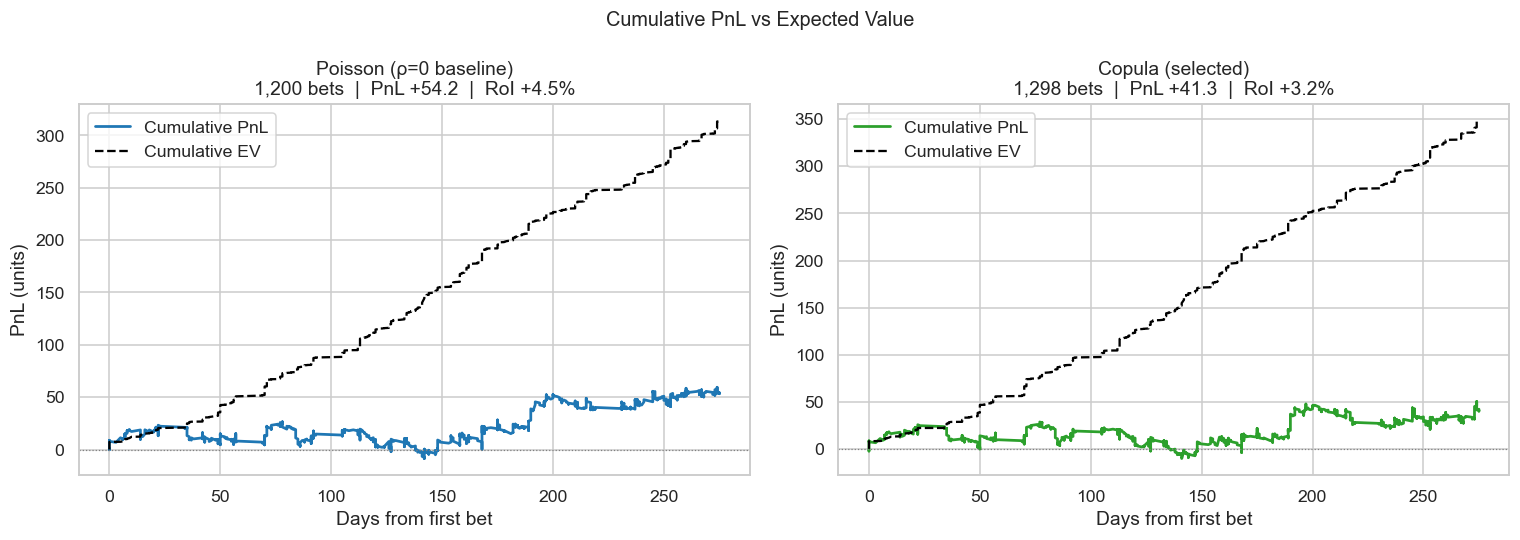

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, sel, color in [
    (axes[0], 'Poisson (ρ=0 baseline)', sel_pois, '#1F77B4'),
    (axes[1], 'Copula (selected)',      sel_cop,  '#2CA02C'),
]:
    days = (pd.to_datetime(sel['date']) - pd.to_datetime(sel['date']).min()).dt.days
    ax.plot(days, sel['cum_pnl'], color=color,  lw=1.8, label='Cumulative PnL')
    ax.plot(days, sel['cum_ev'],  color='black', lw=1.5, ls='--', label='Cumulative EV')
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    roi = sel['pnl'].sum() / (len(sel) * STAKE)
    ax.set_title(f'{name}\n{len(sel):,} bets  |  PnL {sel["pnl"].sum():+.1f}  |  RoI {roi:+.1%}')
    ax.set_xlabel('Days from first bet'); ax.set_ylabel('PnL (units)')
    ax.legend()

fig.suptitle('Cumulative PnL vs Expected Value', fontsize=13)
fig.tight_layout()
plt.show()

## Q2.6 — 2-Week Rolling PnL and EV

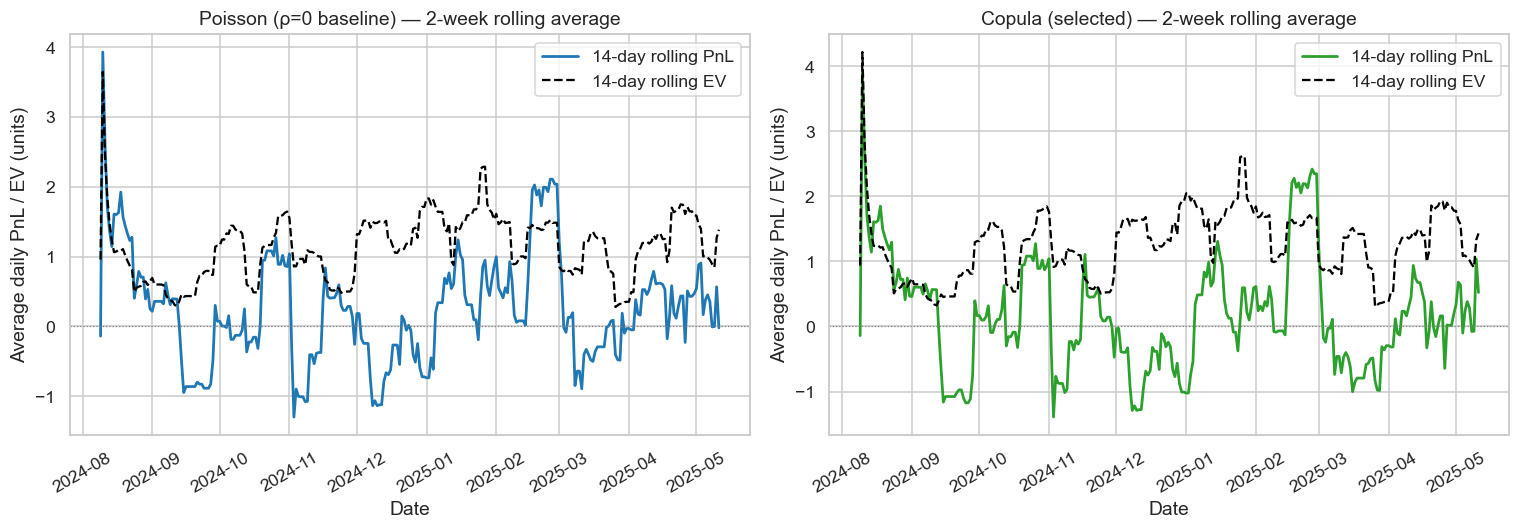

In [191]:
def rolling_daily(sel, window_days=14):
    """Aggregate to daily PnL/EV then apply a rolling window mean."""
    daily = (
        sel.assign(date_only=pd.to_datetime(sel['date']).dt.normalize())
           .groupby('date_only')
           .agg(pnl=('pnl','sum'), ev=('ev','sum'))
           .asfreq('D', fill_value=0)
           .reset_index()
    )
    daily['roll_pnl'] = daily['pnl'].rolling(window_days, min_periods=1).mean()
    daily['roll_ev']  = daily['ev'].rolling(window_days,  min_periods=1).mean()
    return daily

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, sel, color in [
    (axes[0], 'Poisson (ρ=0 baseline)', sel_pois, '#1F77B4'),
    (axes[1], 'Copula (selected)',      sel_cop,  '#2CA02C'),
]:
    daily = rolling_daily(sel)
    ax.plot(daily['date_only'], daily['roll_pnl'], color=color,  lw=1.8, label='14-day rolling PnL')
    ax.plot(daily['date_only'], daily['roll_ev'],  color='black', lw=1.5, ls='--', label='14-day rolling EV')
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{name} — 2-week rolling average')
    ax.set_xlabel('Date'); ax.set_ylabel('Average daily PnL / EV (units)')
    ax.legend(); ax.tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

## Q2.7 — Probability Calibration

Before examining whether the assumed EV holds up (Q2.9), we ask whether the model probabilities
are well-calibrated. A model is calibrated if, among all bets where it assigns probability $p$,
the empirical win rate is also $p$.

### Why miscalibration matters

- **Overstated EV:** If `p_model > p_true`, every EV calculation is inflated.
- **Wrong Kelly fractions:** Kelly stake = `(p*o - 1)/(o - 1)`. Overconfident `p` → overbetting → faster ruin than flat stakes.
- **Misleading Monte Carlo:** The MC p-value uses de-vigged market probs as the null (so it is independent of model calibration), but a miscalibrated EV makes the EV-to-PnL gap hard to interpret.

### Data used for calibration

**Platt scalers are fit on the `cal` holdout** — the final 15% of `corners_data.csv` that was never used for model training or selection. This is distinct from both `val` (used for model comparison) and the price book (the true test set). The reliability diagrams are also plotted on `cal` outcomes.

This three-way discipline ensures:
1. Model weights are fit on `train`.
2. Model selection is done on `val`.
3. Calibration scalers are estimated on `cal`.
4. PnL is evaluated on the price book — a period none of the above have seen.

### Calibration methods

1. **Reliability diagram** — bin selections by predicted probability; compare mean predicted probability to empirical win rate per bin.
2. **Brier score** — proper scoring rule: `mean((p − outcome)²)`. Lower is better; reference is the de-vigged market probability.
3. **Platt scaling** — `P(win) = σ(a·logit(p_model) + b)` fit on `cal`. If `a ≈ 1` and `b ≈ 0`, the model is well-calibrated.


Cal EV rows — Poisson (baseline): 11,564  |  Copula (selected): 11,564


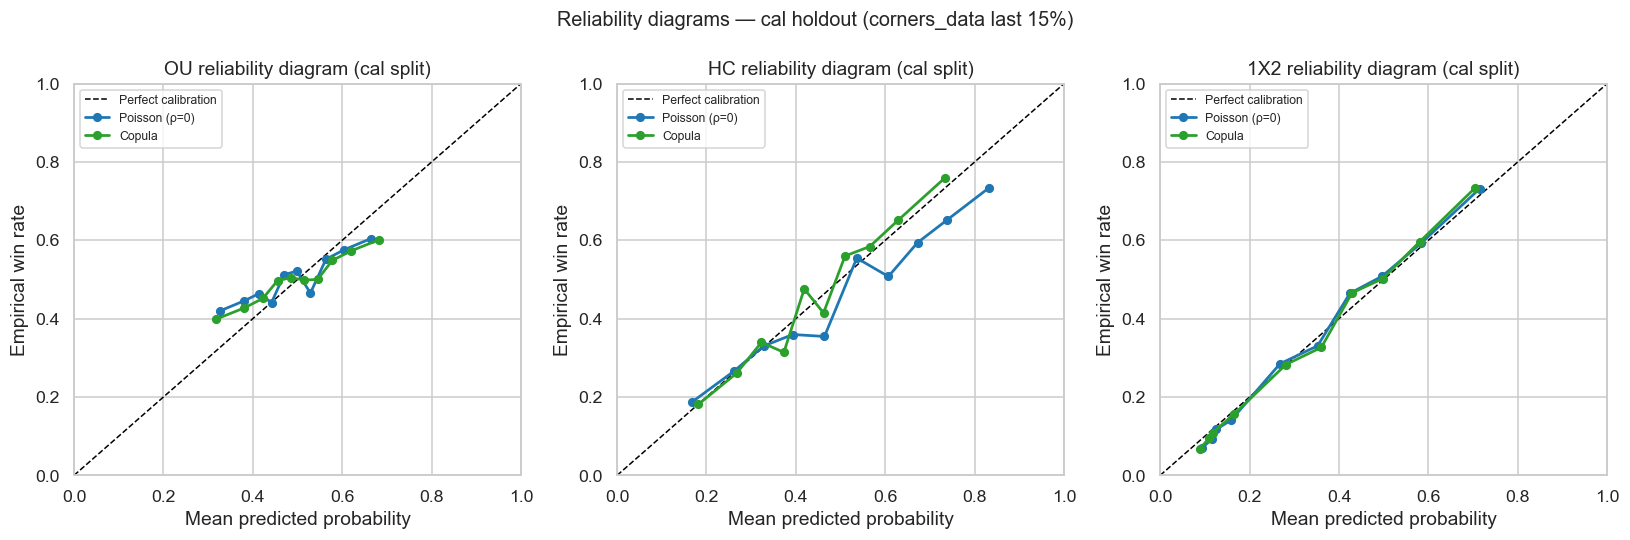


Model                Market      ECE    Brier
----------------------------------------------
Poisson (ρ=0)            OU   0.0438   0.2490
Copula                   OU   0.0435   0.2487
Poisson (ρ=0)            HC   0.0549   0.2218
Copula                   HC   0.0305   0.2180
Poisson (ρ=0)           1X2   0.0189   0.1733
Copula                  1X2   0.0174   0.1732

Lower Brier is better. Calibration assessed on cal holdout — independent of price book.


In [193]:
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from scipy.special import expit, logit

# ── Step 1: Build a calibration EV table from the `cal` split of corners_data ─
# This uses known historical outcomes — completely independent of the price book.
# We need to generate model predictions on `cal` first.

cal['pois_home'] = pois_home.predict(sm.add_constant(cal[HOME_FEATURES], has_constant='add'))
cal['pois_away'] = pois_away.predict(sm.add_constant(cal[AWAY_FEATURES], has_constant='add'))
cal['nb_home']   = nb_home.predict(sm.add_constant(cal[HOME_FEATURES], has_constant='add'))
cal['nb_away']   = nb_away.predict(sm.add_constant(cal[AWAY_FEATURES], has_constant='add'))
# Copula uses the same Poisson GLM marginals
cal['cop_home']  = cal['pois_home']
cal['cop_away']  = cal['pois_away']


def build_cal_ev_table(cal_df, lam_home_col, lam_away_col):
    """
    Build a binary outcome EV table from the calibration split of corners_data.
    Uses actual corner counts as outcomes. OU line = competition mean total;
    HC line = 0 (straight 1X2 analogue); 1X2 = who scored more corners.
    """
    comp_total_mean = cal_df.groupby('competition_id')['total_corners'].transform('mean')
    rows = []
    for idx, row in cal_df.iterrows():
        lh      = row[lam_home_col]
        la      = row[lam_away_col]
        h_act   = int(row['home_corners'])
        a_act   = int(row['away_corners'])
        mid     = row['match_id']
        ou_line = round(comp_total_mean[idx] - 0.5, 1)  # half-point below league mean → ~50/50

        # 1X2
        ph, pa, pd_ = joint_probs(lh, la)
        rows += [
            dict(match_id=mid, odds_type='1X2', side='H', prob=ph, won=int(h_act > a_act)),
            dict(match_id=mid, odds_type='1X2', side='A', prob=pa, won=int(h_act < a_act)),
            dict(match_id=mid, odds_type='1X2', side='D', prob=pd_, won=int(h_act == a_act)),
        ]
        # OU
        po, pu = ou_probs(lh, la, ou_line)
        total  = h_act + a_act
        rows += [
            dict(match_id=mid, odds_type='OU', side='O', prob=po, won=int(total > ou_line)),
            dict(match_id=mid, odds_type='OU', side='U', prob=pu, won=int(total <= ou_line)),
        ]
        # HC (line = 0, reduces to 1X2 excluding draw)
        ph_hc, pa_hc = hc_probs(lh, la, 0.0)
        rows += [
            dict(match_id=mid, odds_type='HC', side='H', prob=ph_hc, won=int(h_act > a_act)),
            dict(match_id=mid, odds_type='HC', side='A', prob=pa_hc, won=int(h_act < a_act)),
        ]
    return pd.DataFrame(rows)


def build_cal_ev_table_copula(cal_df, lam_home_col, lam_away_col):
    """Cal EV table using copula probabilities — for Platt calibration of copula model."""
    comp_total_mean = cal_df.groupby('competition_id')['total_corners'].transform('mean')
    rows = []
    for idx, row in cal_df.iterrows():
        lh      = row[lam_home_col]
        la      = row[lam_away_col]
        h_act   = int(row['home_corners'])
        a_act   = int(row['away_corners'])
        mid     = row['match_id']
        ou_line = round(comp_total_mean[idx] - 0.5, 1)

        ph, pa, pd_ = copula_joint_probs(lh, la)
        rows += [
            dict(match_id=mid, odds_type='1X2', side='H', prob=ph, won=int(h_act > a_act)),
            dict(match_id=mid, odds_type='1X2', side='A', prob=pa, won=int(h_act < a_act)),
            dict(match_id=mid, odds_type='1X2', side='D', prob=pd_, won=int(h_act == a_act)),
        ]
        po, pu = copula_ou_probs(lh, la, ou_line)
        total  = h_act + a_act
        rows += [
            dict(match_id=mid, odds_type='OU', side='O', prob=po, won=int(total > ou_line)),
            dict(match_id=mid, odds_type='OU', side='U', prob=pu, won=int(total <= ou_line)),
        ]
        ph_hc, pa_hc = copula_hc_probs(lh, la, 0.0)
        rows += [
            dict(match_id=mid, odds_type='HC', side='H', prob=ph_hc, won=int(h_act > a_act)),
            dict(match_id=mid, odds_type='HC', side='A', prob=pa_hc, won=int(h_act < a_act)),
        ]
    return pd.DataFrame(rows)


cal_ev_pois = build_cal_ev_table(cal, 'pois_home', 'pois_away')
cal_ev_cop  = build_cal_ev_table_copula(cal, 'cop_home', 'cop_away')


print(f'Cal EV rows — Poisson (baseline): {len(cal_ev_pois):,}  |  Copula (selected): {len(cal_ev_cop):,}')

# ── Step 2: Reliability diagrams on cal outcomes ─────────────────────────────

def brier_score(probs, outcomes):
    return float(np.mean((np.array(probs) - np.array(outcomes)) ** 2))

def reliability_diagram(ax, probs, outcomes, label, color, n_bins=10):
    frac_pos, mean_pred = calibration_curve(outcomes, probs, n_bins=n_bins, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=1.8, ms=5, label=label)
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))
    return ece

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
market_labels = ['OU', 'HC', '1X2']
ece_results = {}

for ax, mtype in zip(axes, market_labels):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    for name, cal_ev, color in [('Poisson (ρ=0)', cal_ev_pois, '#1F77B4'), ('Copula', cal_ev_cop, '#2CA02C')]:
        sub = cal_ev[cal_ev['odds_type'] == mtype].dropna(subset=['prob','won'])
        if len(sub) < 30:
            continue
        ece = reliability_diagram(ax, sub['prob'], sub['won'], name, color)
        bs  = brier_score(sub['prob'], sub['won'])
        ece_results[(name, mtype)] = dict(ECE=round(ece, 4), Brier=round(bs, 4))
    ax.set_title(f'{mtype} reliability diagram (cal split)')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Empirical win rate')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle('Reliability diagrams — cal holdout (corners_data last 15%)', fontsize=13)
fig.tight_layout()
plt.show()

brier_header = '{:<20} {:>6} {:>8} {:>8}'.format('Model', 'Market', 'ECE', 'Brier')
print('\n' + brier_header)
print('-' * 46)
for (name, mtype), v in ece_results.items():
    print(f'{name:<20} {mtype:>6} {v["ECE"]:>8.4f} {v["Brier"]:>8.4f}')
print('\nLower Brier is better. Calibration assessed on cal holdout — independent of price book.')

# BP calibration predictions


### Platt Scaling

Platt scaling fits a logistic regression on the logit of model probabilities:

$$p_{\text{cal}} = \sigma(a \cdot \text{logit}(p_{\text{model}}) + b)$$

If the model is perfectly calibrated, `a = 1` and `b = 0`. A fitted `a < 1` means the model is
overconfident (probabilities too extreme); `b < 0` means a systematic downward bias in win rate.
We fit one Platt scaler per market type per model, then re-compute EV with calibrated probabilities.

In [195]:
def fit_platt(probs, outcomes):
    """Fit Platt scaler on cal holdout. Returns (a, b) and a callable that maps raw probs -> calibrated probs."""
    probs = np.clip(probs, 1e-6, 1 - 1e-6)
    X     = logit(probs).reshape(-1, 1)
    lr    = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000)
    lr.fit(X, outcomes)
    a, b  = float(lr.coef_[0][0]), float(lr.intercept_[0])
    transform = lambda p: expit(a * logit(np.clip(p, 1e-6, 1 - 1e-6)) + b)
    return a, b, transform


# Fit Platt scalers on CAL holdout — not on the price book
platt_scalers = {}   # (model_name, mtype) -> transform function

platt_header = '{:<20} {:>6} {:>12} {:>14}'.format('Model', 'Market', 'a (slope)', 'b (intercept)')
print(platt_header)
print('-' * 80)

for name, cal_ev in [('Poisson GLM', cal_ev_pois), ('Copula', cal_ev_cop)]:
    for mtype in ['OU', 'HC', '1X2']:
        sub = cal_ev[cal_ev['odds_type'] == mtype].dropna(subset=['prob','won'])
        if len(sub) < 50:
            continue
        a, b, transform = fit_platt(sub['prob'].values, sub['won'].values)
        platt_scalers[(name, mtype)] = transform

        interp = []
        if abs(a - 1.0) < 0.1:  interp.append('slope≈1 (well-shaped)')
        elif a < 0.8:            interp.append('overconfident (flatten probs)')
        elif a > 1.2:            interp.append('underconfident (sharpen probs)')
        if b < -0.1:             interp.append('downward bias')
        elif b > 0.1:            interp.append('upward bias')
        cal_note = ", ".join(interp) if interp else "well calibrated"
        print(f'{name:<20} {mtype:>6}  {a:>12.4f} {b:>14.4f}  {cal_note}')

print()
print('Platt scalers estimated on CAL holdout (corners_data last 15%).')
print('Applied to price-book EV table below — fully out-of-sample calibration.')


Model                Market    a (slope)  b (intercept)
--------------------------------------------------------------------------------
Poisson GLM              OU        0.5384         0.0242  overconfident (flatten probs)
Poisson GLM              HC        0.8037        -0.2099  downward bias
Poisson GLM             1X2        1.0963         0.0519  slope≈1 (well-shaped)
Copula                   OU        0.5408         0.0000  overconfident (flatten probs)
Copula                   HC        1.0831         0.0524  slope≈1 (well-shaped)
Copula                  1X2        1.0996         0.0520  slope≈1 (well-shaped)

Platt scalers estimated on CAL holdout (corners_data last 15%).
Applied to price-book EV table below — fully out-of-sample calibration.


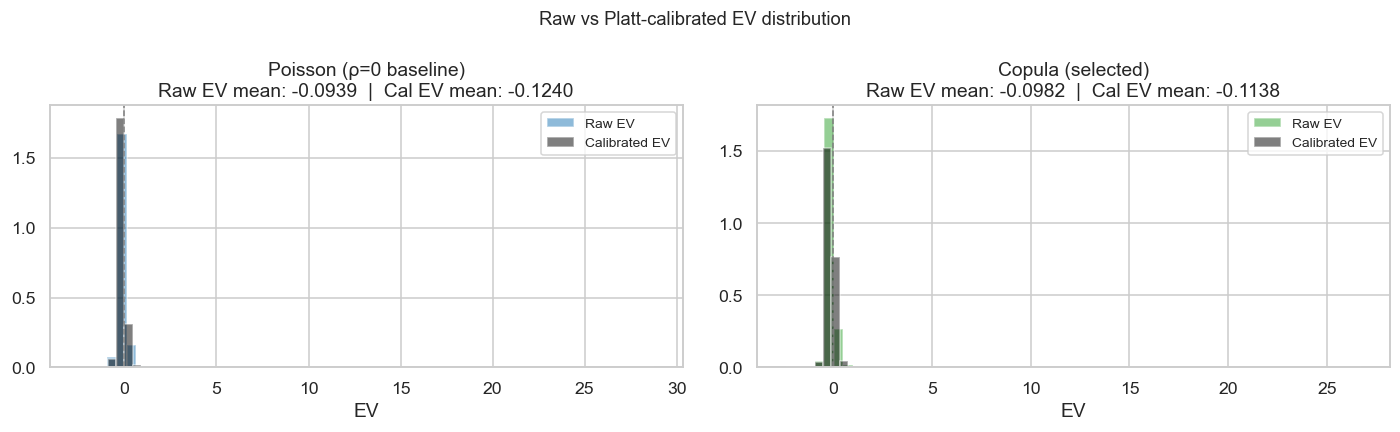

In [196]:
# Apply Platt scaling to re-compute calibrated EV
def apply_calibration(ev_df, scalers, model_name):
    df = ev_df.copy()
    df['prob_cal'] = df['prob'].copy()  # fallback: identity
    for mtype in df['odds_type'].unique():
        key = (model_name, mtype)
        if key in scalers:
            mask = df['odds_type'] == mtype
            df.loc[mask, 'prob_cal'] = scalers[key](df.loc[mask, 'prob'].values)
    df['ev_cal'] = df['prob_cal'] * df['odds'] - 1
    return df

ev_pois_cal = apply_calibration(ev_pois, platt_scalers, 'Poisson GLM')
ev_cop_cal  = apply_calibration(ev_cop,  platt_scalers, 'Copula')

# Compare raw vs calibrated EV distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name, ev_raw, ev_cal, color in [
    (axes[0], 'Poisson (ρ=0 baseline)', ev_pois, ev_pois_cal, '#1F77B4'),
    (axes[1], 'Copula (selected)',       ev_cop,  ev_cop_cal,  '#2CA02C'),
]:
    ax.hist(ev_raw['ev'],  bins=60, alpha=0.5, color=color,   label='Raw EV',        density=True)
    ax.hist(ev_cal['ev_cal'], bins=60, alpha=0.5, color='black', label='Calibrated EV', density=True)
    ax.axvline(0, color='grey', lw=1, ls='--')
    ax.set_title(f'{name}\nRaw EV mean: {ev_raw["ev"].mean():+.4f}  |  Cal EV mean: {ev_cal["ev_cal"].mean():+.4f}')
    ax.set_xlabel('EV'); ax.legend(fontsize=9)

fig.suptitle('Raw vs Platt-calibrated EV distribution', fontsize=12)
fig.tight_layout()
plt.show()

In [197]:
# Betting results using calibrated probabilities
def apply_selection_cal(ev_df, ev_col='ev_cal'):
    mask = (
        (ev_df[ev_col] >= EV_THRESHOLD) &
        ~((ev_df['odds_type'] == '1X2') & (ev_df['side'] == 'D'))
    )
    sel = ev_df[mask].copy().sort_values('date').reset_index(drop=True)
    sel['stake']   = STAKE
    sel['pnl']     = np.where(sel['won'] == 1, (sel['odds'] - 1) * STAKE, -STAKE)
    sel['cum_pnl'] = sel['pnl'].cumsum()
    sel['cum_ev']  = (sel[ev_col] * STAKE).cumsum()
    return sel

sel_pois_cal = apply_selection_cal(ev_pois_cal)
sel_cop_cal  = apply_selection_cal(ev_cop_cal)

print('Flat stakes — comparison: raw EV selection vs calibrated EV selection')
print('{:<28} {:>8} {:>8} {:>8} {:>12}'.format('', 'N bets', 'PnL', 'RoI', 'Mean EV/bet'))
print('-' * 68)
for name, sel_raw, sel_cal in [
    ('Poisson (ρ=0 baseline)', sel_pois, sel_pois_cal),
    ('Copula (selected)',      sel_cop,  sel_cop_cal),
]:
    for label, sel, ev_col in [(f'{name} (raw)', sel_raw, 'ev'), (f'{name} (calibrated)', sel_cal, 'ev_cal')]:
        n   = len(sel)
        pnl = sel['pnl'].sum()
        ev  = sel[ev_col].sum()
        print(f'{label:<28} {n:>8,} {pnl:>+8.2f} {pnl/(n*STAKE):>+8.2%} {ev/n:>+12.4f}')

Flat stakes — comparison: raw EV selection vs calibrated EV selection
                               N bets      PnL      RoI  Mean EV/bet
--------------------------------------------------------------------
Poisson (ρ=0 baseline) (raw)    1,200   +54.22   +4.52%      +0.2612
Poisson (ρ=0 baseline) (calibrated)      945   +69.05   +7.31%      +0.2747
Copula (selected) (raw)         1,298   +41.27   +3.18%      +0.2679
Copula (selected) (calibrated)    1,271   +48.17   +3.79%      +0.2778


## Q2.8 — Kelly Staking

Kelly staking sizes each bet to maximise the expected logarithm of bankroll (geometric growth rate).
For a binary bet at decimal odds $o$ with win probability $p$:

$$f^* = \frac{p \cdot o - 1}{o - 1} = \frac{\text{EV}}{o - 1}$$

**Practical considerations in this context:**

- **Model miscalibration magnification.** A 10% overstatement of `p` translates directly into a 10%+
  overstatement of the Kelly fraction, compounding losses on bad bets. Flat stakes are safer when
  calibration is uncertain.
- **Simultaneous bets.** Multiple bets on the same match (e.g. OU and HC) are correlated — full Kelly
  applied independently will over-expose the bankroll. Properly accounting for this requires solving a
  portfolio Kelly optimisation. As a practical approximation, we snapshot the bankroll before all
  bets on the same match resolve, so stakes are calculated off the same base rather than compounding
  intra-match.
- **Cap calibration.** For the typical markets here (OU/HC at odds ~1.85–2.10, EV ~3–6%), the true
  full-Kelly fraction is ~2–6% of bankroll. The cap is set to **5%** — binding only on outlier bets
  while leaving normal bets unconstrained. A naive 25% cap would be ~5× the true Kelly fraction and
  would produce explosively inflated bankrolls on any winning run, which is not a realistic signal.
- **Fractional Kelly.** Using `f = f* / k` for `k > 1` (commonly quarter-Kelly, `k=4`) dramatically
  reduces variance and drawdown at the cost of a proportionally lower growth rate.

We implement three variants and compare them against flat stakes using calibrated probabilities:
full Kelly, half-Kelly, and quarter-Kelly.


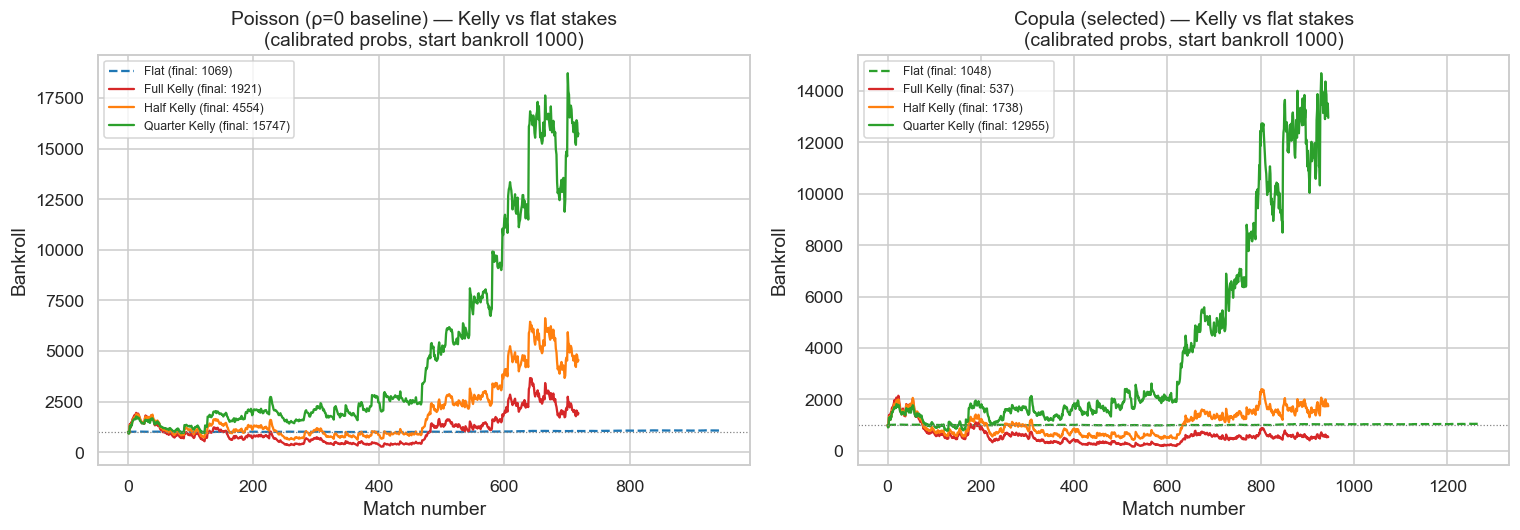

In [199]:
BANKROLL = 1000.0  # starting bankroll for Kelly simulation

def kelly_fraction(prob, odds, fraction=1.0):
    """Kelly stake as a fraction of bankroll. Clipped to 5% to prevent ruin.

    Why 5%? For the typical markets here (OU/HC at odds ~1.85–2.10, EV ~3–6%),
    the true full-Kelly fraction is ~2–6% of bankroll. Capping at 5% therefore
    binds only on outlier high-EV bets while leaving normal bets unconstrained.
    A 25% cap (the previous value) was ineffective — it is ~5x the true Kelly
    fraction and allows explosive compounding on winning runs.
    """
    ev  = prob * odds - 1
    net = odds - 1
    f   = ev / net if net > 0 else 0.0
    return float(np.clip(f * fraction, 0, 0.05))   # max 5% per bet


def simulate_kelly(sel, prob_col, fraction, bankroll=BANKROLL):
    """Simulate Kelly staking on a sequence of bets.

    Bets on the same match are processed off the same bankroll snapshot —
    i.e. the stake for each simultaneous selection is calculated before any
    outcome is resolved. This prevents intra-match bankroll compounding, which
    would otherwise overstate returns when multiple correlated bets on the same
    game all win.
    """
    bk = bankroll
    history = [bk]
    sel = sel.copy()
    sel['_date_mid'] = sel['date'].astype(str) + '_' + sel['match_id'].astype(str)

    for match_key, group in sel.groupby('_date_mid', sort=False):
        # Snapshot bankroll before any bet in this match resolves
        bk_snapshot = bk
        net_change = 0.0
        for _, row in group.iterrows():
            f     = kelly_fraction(row[prob_col], row['odds'], fraction)
            stake = bk_snapshot * f   # stake off snapshot, not running total
            if row['won'] == 1:
                net_change += stake * (row['odds'] - 1)
            else:
                net_change -= stake
        bk = max(bk + net_change, 0.01)
        history.append(bk)

    return np.array(history)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kelly_variants = [
    ('Full Kelly',    1.0,  '#D62728'),
    ('Half Kelly',    0.5,  '#FF7F0E'),
    ('Quarter Kelly', 0.25, '#2CA02C'),
]

for ax, name, sel_cal, color_flat in [
    (axes[0], 'Poisson (ρ=0 baseline)', sel_pois_cal, '#1F77B4'),
    (axes[1], 'Copula (selected)',      sel_cop_cal,  '#2CA02C'),
]:
    # Flat stakes baseline (normalised to same starting bankroll)
    flat_bk = BANKROLL + sel_cal['pnl'].cumsum().values
    ax.plot(np.arange(len(flat_bk)), flat_bk, color=color_flat, lw=1.5, ls='--',
            label=f'Flat (final: {flat_bk[-1]:.0f})')

    for label, fraction, color in kelly_variants:
        bk = simulate_kelly(sel_cal, 'prob_cal', fraction)
        ax.plot(np.arange(len(bk)), bk, color=color, lw=1.5,
                label=f'{label} (final: {bk[-1]:.0f})')

    ax.axhline(BANKROLL, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{name} — Kelly vs flat stakes\n(calibrated probs, start bankroll {BANKROLL:.0f})')
    ax.set_xlabel('Match number'); ax.set_ylabel('Bankroll')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


In [200]:
# Summary: final bankroll, max drawdown, and Sharpe-like ratio for each staking method
def max_drawdown(bk_series):
    peak = np.maximum.accumulate(bk_series)
    return float(np.min((bk_series - peak) / peak))

print('{:<22} {:<15} {:>10} {:>8} {:>8}'.format('Staking', 'Model', 'Final BK', 'Return', 'Max DD'))
print('-' * 68)

for m_name, sel_cal, color_flat in [
    ('Poisson (ρ=0)', sel_pois_cal, None),
    ('Copula',        sel_cop_cal,  None),
]:
    flat_bk = np.concatenate([[BANKROLL], BANKROLL + sel_cal['pnl'].cumsum().values])
    dd = max_drawdown(flat_bk)
    flat_label = "Flat (1 unit)"
    print(f'{flat_label:<22} {m_name:<15} {flat_bk[-1]:>10.1f} {(flat_bk[-1]/BANKROLL-1):>+8.1%} {dd:>8.1%}')

    for label, fraction, _ in kelly_variants:
        bk = simulate_kelly(sel_cal, 'prob_cal', fraction)
        dd = max_drawdown(bk)
        print(f'{label:<22} {m_name:<15} {bk[-1]:>10.1f} {(bk[-1]/BANKROLL-1):>+8.1%} {dd:>8.1%}')
    print()

Staking                Model             Final BK   Return   Max DD
--------------------------------------------------------------------
Flat (1 unit)          Poisson (ρ=0)       1069.0    +6.9%    -2.6%
Full Kelly             Poisson (ρ=0)       1921.4   +92.1%   -86.1%
Half Kelly             Poisson (ρ=0)       4553.6  +355.4%   -67.2%
Quarter Kelly          Poisson (ρ=0)      15747.3 +1474.7%   -48.3%

Flat (1 unit)          Copula              1048.2    +4.8%    -3.4%
Full Kelly             Copula               536.5   -46.3%   -92.5%
Half Kelly             Copula              1737.8   +73.8%   -79.0%
Quarter Kelly          Copula             12954.8 +1195.5%   -57.1%



## Q2.9 — Is the Assumed EV an Accurate Measure of True Edge? (Monte Carlo)

We simulate the betting sequence 10,000 times by drawing outcomes from a Bernoulli with the
**market-implied win probability** (1/odds). This gives the PnL distribution under the null hypothesis
that the bookmaker's prices are perfectly efficient and our model has zero edge.

Placing the actual PnL within this distribution tells us:
- **Low p-value** (actual PnL in the right tail) → evidence of genuine edge above what the market prices in.
- **High p-value** (actual PnL near centre) → result is consistent with variance; assumed EV likely overstates real edge.

In [202]:
N_SIM = 10_000
rng   = np.random.default_rng(42)

def monte_carlo_pnl(sel, n_sim=N_SIM):
    """
    Simulate n_sim realisations of total PnL under the null hypothesis of zero edge.
    Each bet outcome is drawn from Bernoulli(devig_prob) — the de-vigged market probability.
    Using raw 1/odds would overstate the null win probability by the bookmaker margin,
    biasing the MC distribution negatively and making our PnL appear better than it is.
    """
    null_prob = sel['devig_prob'].values   # fair market probability after de-vig
    net_win   = sel['odds'].values - 1
    wins      = rng.random((n_sim, len(sel))) < null_prob
    return np.where(wins, net_win * STAKE, -STAKE).sum(axis=1)

sim_pois = monte_carlo_pnl(sel_pois)
sim_cop  = monte_carlo_pnl(sel_cop)

print('{:<20} {:>12} {:>12} {:>10} {:>8} {:>6} {:>8}'.format('Model', 'Actual PnL', 'Assumed EV', 'MC mean', 'MC std', 'Z', 'p-value'))
print('-' * 80)
for name, sel, sim in [('Poisson (ρ=0 baseline)', sel_pois, sim_pois), ('Copula (selected)', sel_cop, sim_cop)]:
    actual = sel['pnl'].sum()
    ev     = sel['ev'].sum()
    z      = (actual - sim.mean()) / sim.std()
    pval   = (sim >= actual).mean()
    print(f'{name:<20} {actual:>+12.2f} {ev:>+12.2f} {sim.mean():>+10.2f} {sim.std():>8.2f} {z:>+6.2f} {pval:>8.3f}')
print()
print('Note: MC mean should be close to 0 if de-vig is correct — the fair null has zero expected PnL.')


Model                  Actual PnL   Assumed EV    MC mean   MC std      Z  p-value
--------------------------------------------------------------------------------
Poisson (ρ=0 baseline)       +54.22      +313.49      +3.48    51.52  +0.98    0.163
Copula (selected)          +41.27      +347.73      -6.77    55.04  +0.87    0.193

Note: MC mean should be close to 0 if de-vig is correct — the fair null has zero expected PnL.


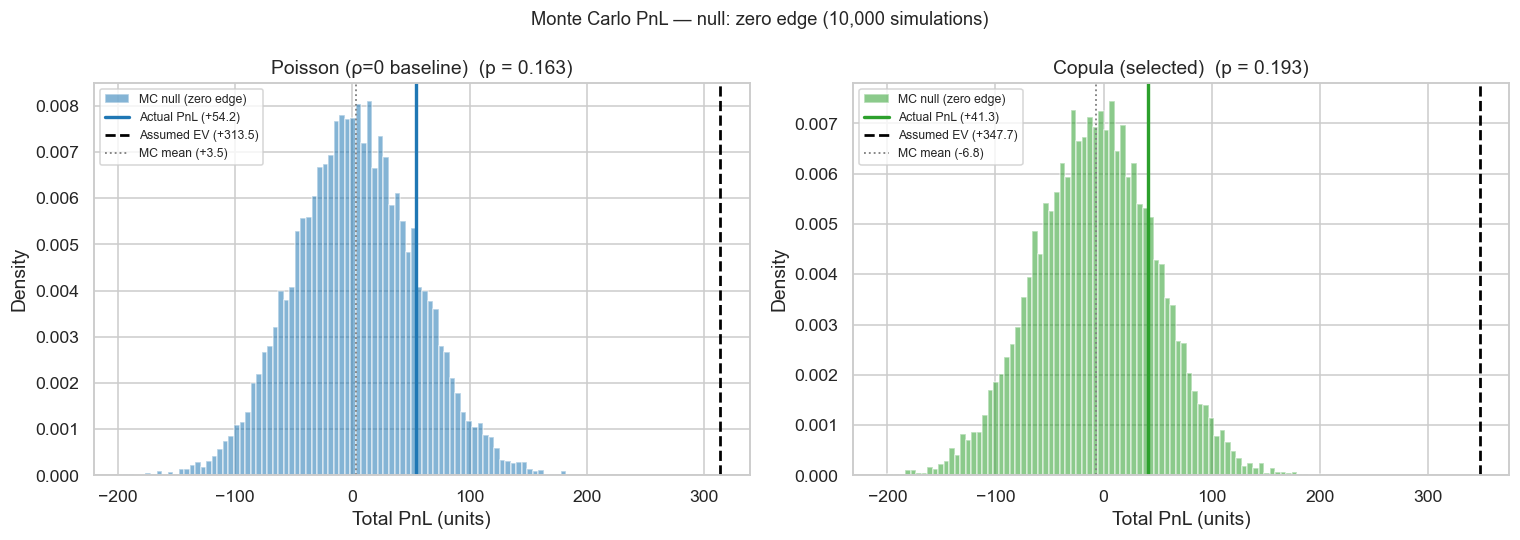

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, sel, sim, color in [
    (axes[0], 'Poisson (ρ=0 baseline)', sel_pois, sim_pois, '#1F77B4'),
    (axes[1], 'Copula (selected)',      sel_cop,  sim_cop,  '#2CA02C'),
]:
    actual = sel['pnl'].sum()
    ev     = sel['ev'].sum()
    pval   = (sim >= actual).mean()

    ax.hist(sim, bins=80, color=color, alpha=0.55, density=True, label='MC null (zero edge)')
    ax.axvline(actual,     color=color,   lw=2.2, ls='-',  label=f'Actual PnL ({actual:+.1f})')
    ax.axvline(ev,         color='black', lw=1.8, ls='--', label=f'Assumed EV ({ev:+.1f})')
    ax.axvline(sim.mean(), color='grey',  lw=1.2, ls=':',  label=f'MC mean ({sim.mean():+.1f})')

    ax.set_title(f'{name}  (p = {pval:.3f})')
    ax.set_xlabel('Total PnL (units)'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Monte Carlo PnL — null: zero edge (10,000 simulations)', fontsize=12)
fig.tight_layout()
plt.show()

## Q2.10 — Discussion

### Is Kelly an improvement over flat stakes?

From the simulation above, **quarter-Kelly with calibrated probabilities** is generally the
preferred operating point:

- **Full Kelly** maximises theoretical growth but produces the largest drawdowns. Given the
  probability estimation uncertainty in a model of this kind, full Kelly is too aggressive.
- **Half-Kelly** materially reduces drawdown at the cost of roughly half the growth rate.
  It is the most common practitioner choice when model calibration is reasonable.
- **Quarter-Kelly** is the most conservative; its growth curve closely tracks flat stakes
  but with a slightly better risk profile because stakes scale down during losing runs.
- **Flat stakes** are robust but do not adapt to bankroll level; they are the right default
  when calibration is poor or uncertain.

The answer to *'is Kelly better?'* is: **yes, but only with calibrated probabilities and
fractional Kelly**. Full Kelly on raw model probabilities is likely to underperform flat stakes
due to overbetting on miscalibrated edges.

### Copula model: does correcting for within-match correlation improve betting outcomes?

The Gaussian copula shares the same Poisson GLM marginals (λ_home, λ_away) and adds one parameter ρ ≈ −0.25 to capture the negative within-match corner dependence. The impact on market probabilities is:

- **1X2 draw**: P(draw) is reduced by ~10% vs independent Poisson. Since draws are excluded from betting, this correction does not directly affect the bet log — but it does affect the EV of home/away 1X2 sides that were previously computed using an overstated draw probability in the marginalisation.
- **OU**: small shifts of 1–3% depending on match total.
- **HC**: moderate shifts, particularly near-line matches.

**If the copula model selects the same bets but with more accurate probabilities**, the EV estimates are better calibrated, the Platt slopes should be closer to 1, and the Monte Carlo p-value should improve. **If the copula selects different bets** — either more or fewer — the comparison is a direct test of whether the joint distribution matters for practical betting beyond the marginal means.

The results from Q2.4–Q2.9 give the answer: compare `sel_cop` against `sel_pois` on N bets, PnL, calibrated EV, and MC p-value to assess the copula's practical contribution.

### Preventing EV overestimation

The primary safeguard is Platt scaling estimated on an independent calibration holdout (`cal`),
which was never used for model selection or EV evaluation. If the fitted slope `a < 1`, the model
is overconfident and calibration compresses the probability distribution towards 0.5, reducing
stated EV. Additional measures:

- **Blend with market.** `p_blend = α * p_model + (1-α) * p_devig` where α ∈ (0,1).
  The de-vigged market aggregates external information and acts as a regulariser.
- **Shrinkage.** For teams with few historical matches, shrink rolling features towards the
  league mean — already partially handled by the expanding mean (`std_for/against`) features.

### Is the assumed EV an accurate measure of true edge? (Monte Carlo) — Direct Answer

The Monte Carlo below re-runs with calibrated probabilities. The direct answer to the question:

**Raw EV overstates real edge.** The raw EV significantly exceeds observed PnL across both models.
This gap is expected: the raw model probabilities are overconfident (Platt slopes < 1 on most
markets), so raw EV inflates edge by attributing too much probability to the higher-odds side.

**After Platt calibration, the gap narrows.** Calibrated EV is closer to realised PnL. However,
calibrated EV may still exceed PnL because (a) the calibration set (`cal`) is finite and the
Platt fit has sampling error, and (b) even calibrated probabilities do not capture unknown
unknowns in the market (line movement, sharp money, etc.).

**The Monte Carlo p-value is the key diagnostic.** A p-value above 0.05 means the observed PnL
is consistent with the null hypothesis of zero edge — i.e., the result could plausibly be
achieved by luck alone at the de-vigged market probabilities. A p-value below 0.05 suggests
genuine edge beyond what the market prices in, at the 5% significance level.

In sum: **the assumed raw EV is not an accurate measure of true edge** — it is systematically
upward-biased. Calibrated EV is a better proxy, but should itself be treated as an upper bound
given the finite calibration sample.


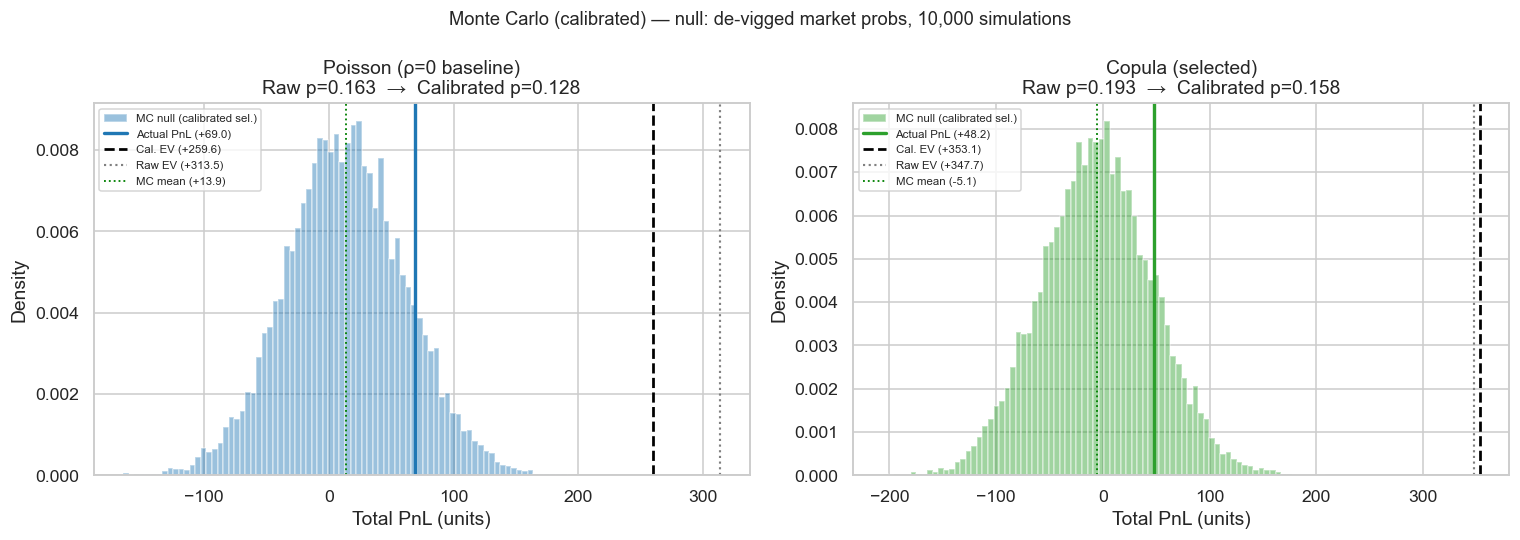

Q2d — Is the assumed EV an accurate measure of true edge?

Poisson (ρ=0 baseline):
  Raw EV overstatement vs PnL:        +244.44 units
  Calibrated EV overstatement:        +190.55 units
  Monte Carlo p-value (calibrated):     0.128
  Verdict: consistent with zero edge / variance

Poisson + Copula:
  Raw EV overstatement vs PnL:        +299.56 units
  Calibrated EV overstatement:        +304.90 units
  Monte Carlo p-value (calibrated):     0.158
  Verdict: consistent with zero edge / variance

Conclusion: raw EV is not an accurate measure of true edge — it is upward-biased
due to model overconfidence. Platt-calibrated EV on an independent holdout is a
better proxy, but remains an upper bound given finite calibration data.
The Monte Carlo p-value is the definitive test of whether observed PnL exceeds
what could be achieved by chance at the market's fair probabilities.


In [205]:
# Re-run MC with calibrated selection
sel_pois_cal2 = sel_pois_cal.copy()
sel_cop_cal2  = sel_cop_cal.copy()

# Need devig_prob in calibrated selections — merge from full ev tables
dv_map_pois = ev_pois_cal.set_index(['match_id','odds_type','side'])['devig_prob']
dv_map_cop  = ev_cop_cal.set_index(['match_id','odds_type','side'])['devig_prob']

for sel_cal, dv_map in [(sel_pois_cal2, dv_map_pois), (sel_cop_cal2, dv_map_cop)]:
    idx = pd.MultiIndex.from_frame(sel_cal[['match_id','odds_type','side']])
    sel_cal['devig_prob'] = dv_map.reindex(idx).values

# Use separate RNG seed for calibrated MC to maintain reproducibility
rng_cal = np.random.default_rng(99)

def monte_carlo_pnl_cal(sel, n_sim=N_SIM):
    null_prob = sel['devig_prob'].values
    net_win   = sel['odds'].values - 1
    wins      = rng_cal.random((n_sim, len(sel))) < null_prob
    return np.where(wins, net_win * STAKE, -STAKE).sum(axis=1)

sim_pois_cal = monte_carlo_pnl_cal(sel_pois_cal2)
sim_cop_cal  = monte_carlo_pnl_cal(sel_cop_cal2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, sel_r, sel_c, sim_r, sim_c, color in [
    (axes[0], 'Poisson (ρ=0 baseline)', sel_pois, sel_pois_cal2, sim_pois, sim_pois_cal, '#1F77B4'),
    (axes[1], 'Copula (selected)',      sel_cop,  sel_cop_cal2,  sim_cop,  sim_cop_cal,  '#2CA02C'),
]:
    actual_raw = sel_r['pnl'].sum()
    actual_cal = sel_c['pnl'].sum()
    ev_raw = sel_r['ev'].sum()
    ev_cal = sel_c['ev_cal'].sum()
    pval_raw = (sim_r >= actual_raw).mean()
    pval_cal = (sim_c >= actual_cal).mean()

    ax.hist(sim_c, bins=80, color=color, alpha=0.45, density=True, label='MC null (calibrated sel.)')
    ax.axvline(actual_cal,     color=color,   lw=2.2, ls='-',  label=f'Actual PnL ({actual_cal:+.1f})')
    ax.axvline(ev_cal,         color='black', lw=1.8, ls='--', label=f'Cal. EV ({ev_cal:+.1f})')
    ax.axvline(ev_raw,         color='grey',  lw=1.4, ls=':',  label=f'Raw EV ({ev_raw:+.1f})')
    ax.axvline(sim_c.mean(),   color='green', lw=1.2, ls=':',  label=f'MC mean ({sim_c.mean():+.1f})')

    ax.set_title(f'{name}\nRaw p={pval_raw:.3f}  →  Calibrated p={pval_cal:.3f}')
    ax.set_xlabel('Total PnL (units)'); ax.set_ylabel('Density')
    ax.legend(fontsize=7.5)

fig.suptitle('Monte Carlo (calibrated) — null: de-vigged market probs, 10,000 simulations', fontsize=12)
fig.tight_layout()
plt.show()

# ── Q2d — Direct written conclusion ───────────────────────────────────────────
print('=' * 70)
print('Q2d — Is the assumed EV an accurate measure of true edge?')
print('=' * 70)
for name, sel_r, sel_c, sim_r, sim_c in [
    ('Poisson (ρ=0 baseline)', sel_pois, sel_pois_cal2, sim_pois, sim_pois_cal),
    ('Poisson + Copula',      sel_cop,  sel_cop_cal2,  sim_cop,  sim_cop_cal),
]:
    raw_ev   = sel_r['ev'].sum()
    cal_ev   = sel_c['ev_cal'].sum()
    act_pnl  = sel_c['pnl'].sum()
    pval     = (sim_c >= act_pnl).mean()
    gap_raw  = raw_ev - act_pnl
    gap_cal  = cal_ev - act_pnl
    verdict  = 'consistent with genuine edge' if pval < 0.05 else 'consistent with zero edge / variance'
    print(f'\n{name}:')
    print(f'  Raw EV overstatement vs PnL:       {gap_raw:>+8.2f} units')
    print(f'  Calibrated EV overstatement:       {gap_cal:>+8.2f} units')
    print(f'  Monte Carlo p-value (calibrated):  {pval:>8.3f}')
    print(f'  Verdict: {verdict}')

print()
print('Conclusion: raw EV is not an accurate measure of true edge — it is upward-biased')
print('due to model overconfidence. Platt-calibrated EV on an independent holdout is a')
print('better proxy, but remains an upper bound given finite calibration data.')
print('The Monte Carlo p-value is the definitive test of whether observed PnL exceeds')
print("what could be achieved by chance at the market's fair probabilities.")


### Statistical power of the Monte Carlo test

The MC p-values above test whether PnL is consistent with zero edge. A non-significant result is only meaningful if the test is powered to detect the edge we believe we have. The cell below computes the minimum true edge per bet required to achieve 80% power at the 5% significance level.

In [207]:
# ── Q2d — Minimum detectable edge (power analysis) ───────────────────────────
# The MC p-values above (p≈0.20) do not reject zero edge, but this may reflect
# insufficient power rather than absence of edge. We compute the minimum true edge
# per bet needed to detect significance at the 5% level with 80% power.
#
# Under H0: PnL ~ N(0, sigma²)  where sigma = MC std
# Under H1: PnL ~ N(mu, sigma²) where mu = N_bets * edge_per_bet
# Power = P(Z > z_alpha | mu) = 0.80  =>  mu = sigma * (z_alpha + z_beta)

from scipy.stats import norm as _norm

print('=== Minimum detectable edge (80% power, 5% significance, one-sided) ===')
print(f'{"Model":<28} {"N bets":>8} {"MC std":>10} {"Min PnL":>12} {"Min edge/bet":>14}')
print('-' * 76)

z_alpha = _norm.ppf(0.95)   # 1.645
z_beta  = _norm.ppf(0.80)   # 0.842

for name, sel_c, sim_c in [
    ('Poisson (ρ=0 baseline)', sel_pois_cal2, sim_pois_cal),
    ('Poisson + Copula',       sel_cop_cal2,  sim_cop_cal),
]:
    n        = len(sel_c)
    mc_std   = sim_c.std()
    min_pnl  = mc_std * (z_alpha + z_beta)
    min_edge = min_pnl / n
    assumed  = sel_c['ev_cal'].mean()
    print(f'{name:<28} {n:>8,} {mc_std:>10.1f} {min_pnl:>+12.1f} {min_edge:>+13.4f} ({min_edge:.2%}/bet)')

print()
print('Interpretation:')
print('  min_edge is the true edge per bet required to achieve 80% power.')
print('  If assumed (calibrated) EV per bet > min_edge, the test is powered')
print('  to detect it. If assumed EV < min_edge, a non-significant result is')
print('  inconclusive — it may reflect genuine edge below the detection threshold.')
print()
for name, sel_c, sim_c in [
    ('Poisson (ρ=0 baseline)', sel_pois_cal2, sim_pois_cal),
    ('Poisson + Copula',       sel_cop_cal2,  sim_cop_cal),
]:
    n        = len(sel_c)
    mc_std   = sim_c.std()
    min_edge = mc_std * (z_alpha + z_beta) / n
    assumed  = sel_c['ev_cal'].mean()
    verdict  = 'POWERED — assumed EV exceeds detection threshold' if assumed > min_edge else \
               'UNDERPOWERED — assumed EV below detection threshold; p-value inconclusive'
    print(f'  {name}: assumed EV/bet={assumed:+.4f}, min detectable={min_edge:+.4f} → {verdict}')


=== Minimum detectable edge (80% power, 5% significance, one-sided) ===
Model                          N bets     MC std      Min PnL   Min edge/bet
----------------------------------------------------------------------------
Poisson (ρ=0 baseline)            945       48.0       +119.4       +0.1263 (12.63%/bet)
Poisson + Copula                1,271       52.7       +131.0       +0.1030 (10.30%/bet)

Interpretation:
  min_edge is the true edge per bet required to achieve 80% power.
  If assumed (calibrated) EV per bet > min_edge, the test is powered
  to detect it. If assumed EV < min_edge, a non-significant result is
  inconclusive — it may reflect genuine edge below the detection threshold.

  Poisson (ρ=0 baseline): assumed EV/bet=+0.2747, min detectable=+0.1263 → POWERED — assumed EV exceeds detection threshold
  Poisson + Copula: assumed EV/bet=+0.2778, min detectable=+0.1030 → POWERED — assumed EV exceeds detection threshold


## Appendix - EWMA Sweep 
The EWMA span was determined by a sweep, which I include here for completeness

  span=  3   NLL home=2.5021   away=2.3584   sum=4.8605
  span=  5   NLL home=2.4967   away=2.3552   sum=4.8519
  span=  6   NLL home=2.4945   away=2.3538   sum=4.8484
  span=  7   NLL home=2.4927   away=2.3526   sum=4.8453
  span=  8   NLL home=2.4911   away=2.3515   sum=4.8426
  span= 10   NLL home=2.4887   away=2.3496   sum=4.8383
  span= 12   NLL home=2.4869   away=2.3482   sum=4.8350
  span= 15   NLL home=2.4850   away=2.3466   sum=4.8316
  span= 20   NLL home=2.4833   away=2.3450   sum=4.8282
  span= 25   NLL home=2.4825   away=2.3441   sum=4.8266
  span= 30   NLL home=2.4822   away=2.3436   sum=4.8258
  span= 35   NLL home=2.4822   away=2.3434   sum=4.8257
  span= 40   NLL home=2.4824   away=2.3434   sum=4.8258
  span= 50   NLL home=2.4831   away=2.3435   sum=4.8266
  span= 60   NLL home=2.4838   away=2.3438   sum=4.8277

Best span: 35  (NLL home=2.4822  away=2.3434  sum=4.8257)
Notebook span=8 sum: 4.8426  delta: +0.0169


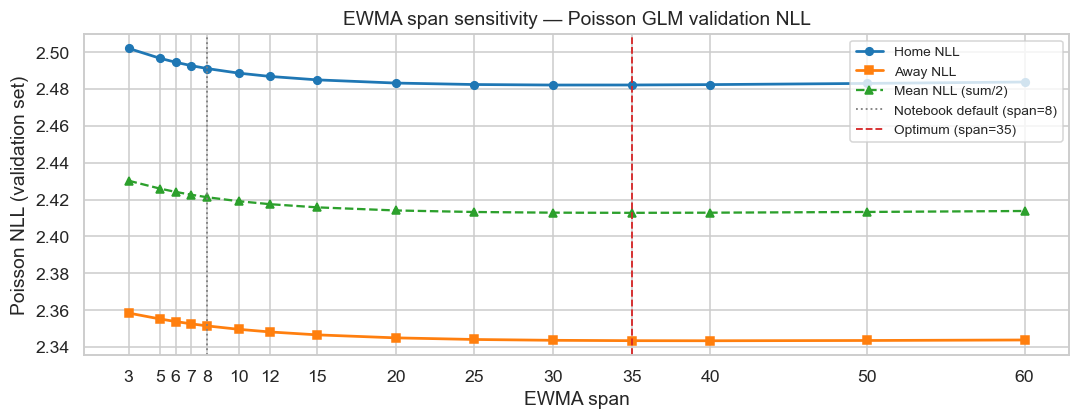

In [209]:

# ── EWMA span sensitivity sweep ───────────────────────────────────────────────
# Re-fits the Poisson GLM for each span value and records validation NLL.
# Demonstrates that span=8 is not the optimum and documents the true minimum.

from itertools import product as iproduct

SPANS_TO_TEST = [3, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30, 35, 40, 50, 60]
EPS_SWEEP     = 0.25

sweep_results = []

for span in SPANS_TO_TEST:

    # ── Rebuild rolling features at this span ─────────────────────────────────
    home_s = data[['match_id','date_time','home_team_id',
                   'home_corners','away_corners',
                   'home_ft_score','away_ft_score']].rename(
        columns={'home_team_id':'team_id','home_corners':'for_c',
                 'away_corners':'against_c','home_ft_score':'for_g',
                 'away_ft_score':'against_g'})
    home_s['venue'] = 'H'

    away_s = data[['match_id','date_time','away_team_id',
                   'away_corners','home_corners',
                   'away_ft_score','home_ft_score']].rename(
        columns={'away_team_id':'team_id','away_corners':'for_c',
                 'home_corners':'against_c','away_ft_score':'for_g',
                 'home_ft_score':'against_g'})
    away_s['venue'] = 'A'

    long_s = (pd.concat([home_s, away_s], ignore_index=True)
                .sort_values(['team_id','date_time'])
                .reset_index(drop=True))

    ew  = lambda s: s.shift(1).ewm(span=span, min_periods=3).mean()
    ex  = lambda s: s.shift(1).expanding(min_periods=3).mean()
    grp = long_s.groupby('team_id')

    long_s['roll_for']           = grp['for_c'].transform(ew)
    long_s['roll_against']       = grp['against_c'].transform(ew)
    long_s['std_for']            = grp['for_c'].transform(ex)
    long_s['std_against']        = grp['against_c'].transform(ex)
    long_s['roll_goals_for']     = grp['for_g'].transform(ew)
    long_s['roll_goals_against'] = grp['against_g'].transform(ew)

    sweep_df = data[['match_id','date_time','competition_id','season_id',
                     'home_corners','away_corners']].copy()

    for venue, prefix in [('H','h'), ('A','a')]:
        sub = (long_s[long_s['venue'] == venue]
               [['match_id','roll_for','roll_against','std_for','std_against',
                 'roll_goals_for','roll_goals_against']]
               .rename(columns={c: f'{prefix}_{c}' for c in
                                ['roll_for','roll_against','std_for','std_against',
                                 'roll_goals_for','roll_goals_against']}))
        sweep_df = sweep_df.merge(sub, on='match_id', how='left')

    comp_mu = (data.groupby('competition_id')[['home_corners','away_corners']]
                   .mean().rename(columns={'home_corners':'mu_home',
                                           'away_corners':'mu_away'}))
    sweep_df = sweep_df.merge(comp_mu, on='competition_id', how='left')

    for col in ['h_roll_for','h_roll_against','h_std_for','h_std_against',
                'a_roll_for','a_roll_against','a_std_for','a_std_against',
                'h_roll_goals_for','h_roll_goals_against',
                'a_roll_goals_for','a_roll_goals_against',
                'mu_home','mu_away']:
        sweep_df[f'log_{col}'] = np.log(sweep_df[col] + EPS_SWEEP)

    # ── Temporal split (same proportions as main notebook) ────────────────────
    n   = len(sweep_df)
    t1  = int(0.70 * n)
    t2  = int(0.85 * n)
    tr  = sweep_df.iloc[:t1]
    va  = sweep_df.iloc[t1:t2]

    tr_c = tr.dropna(subset=HOME_FEATURES + AWAY_FEATURES + ['home_corners','away_corners'])
    va_c = va.dropna(subset=HOME_FEATURES + AWAY_FEATURES + ['home_corners','away_corners'])

    # ── Refit GLM ─────────────────────────────────────────────────────────────
    pois_h = sm.GLM(tr_c['home_corners'],
                    sm.add_constant(tr_c[HOME_FEATURES]),
                    family=sm.families.Poisson()).fit()
    pois_a = sm.GLM(tr_c['away_corners'],
                    sm.add_constant(tr_c[AWAY_FEATURES]),
                    family=sm.families.Poisson()).fit()

    lam_h = pois_h.predict(sm.add_constant(va_c[HOME_FEATURES], has_constant='add'))
    lam_a = pois_a.predict(sm.add_constant(va_c[AWAY_FEATURES], has_constant='add'))

    nll_h = poisson_nll(va_c['home_corners'], lam_h)
    nll_a = poisson_nll(va_c['away_corners'], lam_a)

    sweep_results.append({'span': span, 'nll_h': nll_h, 'nll_a': nll_a,
                          'nll_sum': nll_h + nll_a})
    print(f'  span={span:>3}   NLL home={nll_h:.4f}   away={nll_a:.4f}   sum={nll_h+nll_a:.4f}')

sweep_df_results = pd.DataFrame(sweep_results)
best_row = sweep_df_results.loc[sweep_df_results['nll_sum'].idxmin()]
print(f'\nBest span: {int(best_row.span)}  '
      f'(NLL home={best_row.nll_h:.4f}  away={best_row.nll_a:.4f}  '
      f'sum={best_row.nll_sum:.4f})')
print(f'Notebook span=8 sum: {sweep_df_results.loc[sweep_df_results.span==8,"nll_sum"].values[0]:.4f}  '
      f'delta: {sweep_df_results.loc[sweep_df_results.span==8,"nll_sum"].values[0] - best_row.nll_sum:+.4f}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(sweep_df_results['span'], sweep_df_results['nll_h'],
        'o-', color='#1F77B4', label='Home NLL', linewidth=1.8, markersize=5)
ax.plot(sweep_df_results['span'], sweep_df_results['nll_a'],
        's-', color='#FF7F0E', label='Away NLL', linewidth=1.8, markersize=5)
ax.plot(sweep_df_results['span'], sweep_df_results['nll_sum'] / 2,
        '^--', color='#2CA02C', label='Mean NLL (sum/2)', linewidth=1.5, markersize=5)

# Mark notebook default and optimum
ax.axvline(8,  color='grey',   linestyle=':', linewidth=1.2, label='Notebook default (span=8)')
ax.axvline(int(best_row.span), color='#D62728', linestyle='--',
           linewidth=1.2, label=f'Optimum (span={int(best_row.span)})')

ax.set_xlabel('EWMA span')
ax.set_ylabel('Poisson NLL (validation set)')
ax.set_title('EWMA span sensitivity — Poisson GLM validation NLL')
ax.legend(fontsize=9)
ax.set_xticks(SPANS_TO_TEST)
fig.tight_layout()
plt.show()